In [1]:
import os, json, random, re, shutil
from pathlib import Path
from collections import defaultdict
from itertools import count
from time import perf_counter
from math import sqrt 
from joblib import Parallel, delayed
import joblib
from threadpoolctl import threadpool_limits
from contextlib import contextmanager
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from IPython.display import display
from tqdm.autonotebook import tqdm

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import xgboost as xgb
from packaging.version import Version
from aggregator import FixedModuleAggregator

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from hyperopt.early_stop import no_progress_loss

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

C:\Users\LL331070\AppData\Local\Temp\ipykernel_32128\1734944046.py:20: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Load and process data


In [2]:
# Paths
X_path  = '../data/features_label/processed_X/x_clean_no_scaled_no_imputation.csv'
gene_map_path  = '../data/features_label/co_expression_info/gene_to_feature.csv'
y_path  = '../data/features_label/tca_status_medium.csv'

#  Load X 
X_raw = pd.read_csv(X_path, index_col=0)
gene_to_feature = pd.read_csv(gene_map_path)

# Align X to modules (keep genes that appear in the map)
genes_in_modules = {g for g in gene_to_feature['gene'] if g in X_raw.columns}
X_use = X_raw.loc[:, sorted(genes_in_modules)].astype('float32').copy()
print(f'X_raw: {X_raw.shape} | X_use (in modules): {X_use.shape}')

# Build dict: module -> sorted list of genes
modules = defaultdict(list)
for g, m in gene_to_feature[gene_to_feature['gene'].isin(genes_in_modules)].values:
    modules[m].append(g)
modules = {m: sorted(gs) for m, gs in modules.items()}
print(f'Modules: {len(modules)} | Genes used: {X_use.shape[1]}')

# Load Y (two outputs) 
tca_status = pd.read_csv(y_path, index_col=0)
y_A = tca_status['TCA non canonical'].values
y_B = tca_status['activity TCA non canonical'].values
y = np.vstack([y_A, y_B]).T.astype('float32')
assert len(y) == len(X_use), 'X and y must have the same length'
print('y shape:', y.shape)

X_raw: (513, 18082) | X_use (in modules): (513, 18082)
Modules: 14455 | Genes used: 18082
y shape: (513, 2)


### Train XGBoost

In [ ]:
@contextmanager
def fold_logger(outdir, fold_id: int, also_stdout: bool = True):
    outdir.mkdir(parents=True, exist_ok=True)
    log_path = outdir / f"log_fold_{fold_id}.txt"
    f = open(log_path, "a", buffering=1, encoding="utf-8")
    def log(msg: str):
        ts = datetime.now().strftime("%H:%M:%S")
        line = f"[{ts}] [fold {fold_id}] {msg}"
        if also_stdout:
            print(line, flush=True)
        f.write(line + "\n")
    try:
        yield log, log_path
    finally:
        try:
            f.close()
        except Exception:
            pass

def make_pipeline_xgb(modules, feature_names, seed=42, use_multi_tree: bool = True):
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'n_jobs': 1,
        'random_state': seed,
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.0,
        'reg_lambda': 1.0
    }
    if use_multi_tree:
        params['multi_strategy'] = 'multi_output_tree'

    pipe = Pipeline([
        ('scale_x', StandardScaler(with_mean=True, with_std=True)),
        ('agg', FixedModuleAggregator(modules=modules,
                                      feature_names=list(feature_names),
                                      random_state=seed)),
        ('model', XGBRegressor(**params))
    ])
    return pipe

def to_json_compatible(obj):
    """Converti ricorsivamente tipi numpy in tipi standard per JSON."""
    if isinstance(obj, (np.integer, )):
        return int(obj)
    if isinstance(obj, (np.floating, )):
        return float(obj)
    if isinstance(obj, dict):
        return {to_json_compatible(k): to_json_compatible(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_json_compatible(v) for v in obj]
    return obj


In [100]:
def nested_cv_xgb_phase1(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    outer_cv: KFold,
    inner_cv: KFold,
    hyperopt_space: dict,
    hyperopt_evals: int = 50,
    early_stop: int = 20,
    checkpoint_every: int = 5,
    interim_eval_every: int = 10, 
    use_multi_tree: bool = True,
    use_one_se: bool = True,
    n_jobs_inner: int = 1,
    n_jobs_outer: int = 1,
    outdir=None,
    seed: int = 42,
):
    outdir.mkdir(parents=True, exist_ok=True)
    X = X_df.values.astype(np.float32)
    splits = list(outer_cv.split(X))

    def _run_one_fold(fold_id, tr_idx, te_idx):
        with threadpool_limits(limits=1):
            with fold_logger(outdir, fold_id) as (log, log_path):
                t0 = perf_counter()
                log(f"START fold — train={len(tr_idx)}, test={len(te_idx)}, seed={seed + fold_id}, use_multi_tree={use_multi_tree}")

                X_tr, X_te = X[tr_idx], X[te_idx]
                y_tr, y_te = y_mat[tr_idx], y_mat[te_idx]

                # y-scaling done OUTSIDE the pipeline to inverse-transform predictions
                y_scaler = StandardScaler()
                y_tr_z = y_scaler.fit_transform(y_tr)
                y_te_z = y_scaler.transform(y_te)

                base_pipe = make_pipeline_xgb(modules, X_df.columns, seed=seed + fold_id, use_multi_tree=use_multi_tree)
                base_pipe.set_params(model__n_jobs=1)

                best_loss_so_far = np.inf
                best_params_so_far = None

                # helper: interim eval on TRAIN/TEST with best params so far
                def _interim_eval(k_iter: int, best_plain: dict):
                    if not best_plain:
                        return
                    pipe_chk = make_pipeline_xgb(modules, X_df.columns, seed=seed + fold_id, use_multi_tree=use_multi_tree)
                    # set n_jobs=1 and best params
                    pipe_chk.set_params(model__n_jobs=1, **{f"model__{k}": v for k, v in best_plain.items()})
                    t_fitc = perf_counter()
                    pipe_chk.fit(X_tr, y_tr_z)
                    t_fitc = perf_counter() - t_fitc

                    yhat_tr_z_c = pipe_chk.predict(X_tr)
                    yhat_te_z_c = pipe_chk.predict(X_te)
                    yhat_tr_c = y_scaler.inverse_transform(yhat_tr_z_c)
                    yhat_te_c = y_scaler.inverse_transform(yhat_te_z_c)

                    # per-target + macro
                    r2_tr_list, rmse_tr_list = [], []
                    r2_te_list, rmse_te_list = [], []
                    for j in range(y_mat.shape[1]):
                        r2_tr = r2_score(y_tr[:, j], yhat_tr_c[:, j])
                        rmse_tr = np.sqrt(mean_squared_error(y_tr[:, j], yhat_tr_c[:, j]))
                        r2_te = r2_score(y_te[:, j], yhat_te_c[:, j])
                        rmse_te = np.sqrt(mean_squared_error(y_te[:, j], yhat_te_c[:, j]))
                        r2_tr_list.append(r2_tr); rmse_tr_list.append(rmse_tr)
                        r2_te_list.append(r2_te); rmse_te_list.append(rmse_te)
                    log(
                        f"[PEEK @iter {k_iter}] Interim eval with best-so-far (NO selection): "
                        f"TRAIN R2={np.mean(r2_tr_list):.4f}, RMSE={np.mean(rmse_tr_list):.4f} | "
                        f"TEST R2={np.mean(r2_te_list):.4f}, RMSE={np.mean(rmse_te_list):.4f} "
                        f"(fit {t_fitc:.2f}s)"
                    )

                trial_counter = count(0)

                def obj(p_raw):
                    k = next(trial_counter) + 1
                    p = {
                        'n_estimators':     int(p_raw['n_estimators']),
                        'max_depth':        int(p_raw['max_depth']),
                        'learning_rate':    float(p_raw['learning_rate']),
                        'subsample':        float(p_raw['subsample']),
                        'colsample_bytree': float(p_raw['colsample_bytree']),
                        'colsample_bynode':  float(p_raw.get('colsample_bynode', 1.0)),
                        'reg_alpha':        float(p_raw.get('reg_alpha', 0.0)),
                        'reg_lambda':       float(p_raw.get('reg_lambda', 1.0)),
                        'min_child_weight': float(p_raw.get('min_child_weight', 1.0)),
                        'gamma':            float(p_raw.get('gamma', 0.0)),
                    }
                    param_set = {f"model__{k2}": v2 for k2, v2 in p.items()}
                    pipe = base_pipe
                    pipe.set_params(**param_set)

                    mses = -cross_val_score(
                        pipe, X_tr, y_tr_z,
                        cv=inner_cv, scoring='neg_mean_squared_error',
                        n_jobs=n_jobs_inner
                    )
                    loss = float(mses.mean())
                    loss_sem = float(mses.std(ddof=1) / np.sqrt(inner_cv.get_n_splits()))

                    nonlocal best_loss_so_far, best_params_so_far
                    if loss < best_loss_so_far:
                        best_loss_so_far = loss
                        best_params_so_far = p.copy()
                        log(f"Hyperopt iter {k}: **New best loss = {loss:.6f}**, params = {p}")

                    if (k % checkpoint_every) == 0:
                        log(f"Hyperopt iter {k}: current loss = {loss:.6f}, params = {p}")

                    # Interim monitoring on TEST (no selection), every N eval
                    if interim_eval_every and (k % interim_eval_every == 0):
                        _interim_eval(k, best_params_so_far)

                    return {
                        'loss': loss,
                        'status': STATUS_OK,
                        'loss_sem': loss_sem,
                        **p
                    }

                trials = Trials()
                fmin(
                    fn=obj,
                    space=hyperopt_space,
                    algo=tpe.suggest,
                    max_evals=hyperopt_evals,
                    trials=trials,
                    early_stop_fn=no_progress_loss(early_stop),
                    rstate=np.random.default_rng(seed + fold_id),
                    show_progressbar=False
                )

                # Collect results
                rows = []
                for tr in trials.trials:
                    res = tr['result']
                    if 'loss' in res and np.isfinite(res['loss']):
                        rows.append(res)
                res_df = pd.DataFrame(rows).dropna()
                assert len(res_df) > 0, f"Fold {fold_id}: no valid trials"

                # 1-SE rule or min-loss
                if use_one_se:
                    best_row = res_df.loc[res_df['loss'].idxmin()]
                    thr = float(best_row['loss'] + best_row['loss_sem'])
                    cands = res_df[res_df['loss'] <= thr].copy()
                    chosen = cands.sort_values('loss').iloc[0]
                    log(f"1-SE chosen loss={chosen['loss']:.6f}, threshold={thr:.6f}")
                else:
                    chosen = res_df.loc[res_df['loss'].idxmin()]
                    log(f"Min loss chosen = {chosen['loss']:.6f}")

                # Build best params dicts (with/without 'model__' prefix)
                keys_all = [
                    'n_estimators','max_depth','learning_rate','subsample','colsample_bynode', 
                    'colsample_bytree','reg_alpha','reg_lambda','min_child_weight','gamma'
                ]
                best_params_plain = {}
                best_params = {}
                for k2 in keys_all:
                    if k2 in chosen:
                        best_params_plain[k2] = chosen[k2]
                        best_params[f"model__{k2}"] = chosen[k2]

                log("Parameters chosen for fold:\n" + json.dumps(to_json_compatible(best_params_plain), indent=2))

                # Final fit on TRAIN with chosen params
                t_fit = perf_counter()
                base_pipe.set_params(**best_params)
                base_pipe.fit(X_tr, y_tr_z)
                fit_time = perf_counter() - t_fit
                log(f"Fitted pipeline on TRAIN in {fit_time:.2f}s")

                # Predict
                yhat_tr_z = base_pipe.predict(X_tr)
                yhat_te_z = base_pipe.predict(X_te)
                yhat_tr = y_scaler.inverse_transform(yhat_tr_z)
                yhat_te = y_scaler.inverse_transform(yhat_te_z)

                # Save TRAIN predictions
                df_tr = pd.DataFrame({'sample_id': X_df.index[tr_idx]})
                for j in range(y_mat.shape[1]):
                    df_tr[f'y_true_{j}'] = y_tr[:, j]
                    df_tr[f'y_pred_{j}'] = yhat_tr[:, j]
                    df_tr[f'resid_{j}'] = y_tr[:, j] - yhat_tr[:, j]
                tr_path = outdir / f"predictions_fold_{fold_id}_train.csv"
                df_tr.to_csv(tr_path, index=False)
                log(f"Saved train predictions to {tr_path}")

                # Save TEST predictions
                df_te = pd.DataFrame({'sample_id': X_df.index[te_idx]})
                for j in range(y_mat.shape[1]):
                    df_te[f'y_true_{j}'] = y_te[:, j]
                    df_te[f'y_pred_{j}'] = yhat_te[:, j]
                    df_te[f'resid_{j}'] = y_te[:, j] - yhat_te[:, j]
                te_path = outdir / f"predictions_fold_{fold_id}_test.csv"
                df_te.to_csv(te_path, index=False)
                log(f"Saved test predictions to {te_path}")

                # Log per-target metrics (TRAIN & TEST)
                for j in range(y_mat.shape[1]):
                    r2_tr = r2_score(y_tr[:, j], yhat_tr[:, j])
                    mse_tr = mean_squared_error(y_tr[:, j], yhat_tr[:, j])
                    rmse_tr = np.sqrt(mse_tr)
                    log(f"TRAIN target {j}: R2={r2_tr:.4f}, RMSE={rmse_tr:.4f}")

                    r2_te = r2_score(y_te[:, j], yhat_te[:, j])
                    mse_te = mean_squared_error(y_te[:, j], yhat_te[:, j])
                    rmse_te = np.sqrt(mse_te)
                    log(f"TEST target {j}: R2={r2_te:.4f}, RMSE={rmse_te:.4f}")

                # Persist model
                model_path = outdir / f"pipeline_fold_{fold_id}.joblib"
                joblib.dump(base_pipe, model_path)
                log(f"Saved pipeline model to {model_path}")

                # Metadata (includes both prefixed and plain params)
                meta = {
                    'fold': fold_id,
                    'seed': seed + fold_id,
                    'use_multi_tree': use_multi_tree,
                    'best_params': best_params,                 # with 'model__' prefix
                    'best_params_plain': best_params_plain,     # plain, easier to read
                    'inner_best_loss': chosen['loss'],
                    'inner_loss_sem': chosen.get('loss_sem', np.nan),
                    'n_train': len(tr_idx),
                    'n_test': len(te_idx),
                    'interim_eval_every': interim_eval_every,   # <- NEW: recorded for traceability
                    'checkpoint_every': checkpoint_every
                }
                meta_clean = to_json_compatible(meta)
                meta_path = outdir / f"metadata_fold_{fold_id}.json"
                with open(meta_path, 'w') as f:
                    json.dump(meta_clean, f, indent=2)
                log(f"Saved metadata to {meta_path}")

                log(f"END fold in {perf_counter() - t0:.2f}s")
                return meta_clean

    tasks = [(k+1, tr, te) for k, (tr, te) in enumerate(splits)]
    results = Parallel(n_jobs=n_jobs_outer)(
        delayed(_run_one_fold)(fold_id, tr_idx, te_idx)
        for fold_id, tr_idx, te_idx in tasks
    )

    all_meta = pd.DataFrame(results)
    all_meta.to_csv(outdir / "all_metadata.csv", index=False)
    return all_meta


In [69]:
# CV splits
outer_cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
inner_cv = KFold(n_splits=5,  shuffle=True, random_state=SEED)

#### 1° Space

In [ ]:
# Hyperopt search space
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_1")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [ ]:
hyperopt_space_xgb = {
    "n_estimators":      hp.qloguniform("n_estimators", np.log(700),  np.log(2000), 1),
    "learning_rate":     hp.loguniform("learning_rate", np.log(0.02), np.log(0.07)),  
    "max_depth":         hp.choice("max_depth", [2, 3, 4, 5]),            
    "min_child_weight":  hp.qloguniform("min_child_weight", np.log(5), np.log(40), 1),
    "subsample":         hp.uniform("subsample", 0.50, 0.80),
    "colsample_bytree":  hp.uniform("colsample_bytree", 0.40, 0.70),
    "reg_lambda":        hp.loguniform("reg_lambda", np.log(3.0), np.log(200.0)),
    "reg_alpha":         hp.loguniform("reg_alpha",  np.log(1e-3), np.log(10.0)),
    "gamma":             hp.loguniform("gamma",      np.log(1e-3), np.log(5.0)),  
}

evals = 20
early_stop = 10

In [ ]:
nested_cv_xgb_phase1(
    X_df = X_use,
    y_mat = y,
    modules = modules,
    use_multi_tree = True,
    outer_cv = outer_cv,
    inner_cv = inner_cv,
    hyperopt_space = hyperopt_space_xgb,
    hyperopt_evals = evals,
    early_stop= early_stop,
    checkpoint_every = 5,
    use_one_se = True,
    n_jobs_inner = 5,
    n_jobs_outer = 5,
    outdir = OUTDIR,
    seed = SEED,
)

#### Space 2

In [ ]:
# Hyperopt search space
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_2")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [ ]:
hyperopt_space_xgb1 = {
    "n_estimators": hp.qloguniform("n_estimators", np.log(300),  np.log(1200), 1),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.05)),
    "max_depth": hp.choice("max_depth", [2, 3, 4]),
    "min_child_weight":  hp.qloguniform("min_child_weight", np.log(30), np.log(150), 1),
    "subsample":  hp.uniform("subsample", 0.5, 0.7),
    "colsample_bytree":  hp.uniform("colsample_bytree", 0.4, 0.6),
    # "colsample_bynode":  hp.uniform("colsample_bynode", 0.5, 0.9),
    "reg_lambda": hp.loguniform("reg_lambda", np.log(20.0), np.log(800.0)),
    "reg_alpha":  hp.loguniform("reg_alpha",  np.log(0.2),  np.log(120.0)),
    "gamma":  hp.loguniform("gamma",  np.log(0.5),  np.log(20.0)),
}

evals = 50
early_stop = 20

In [82]:
nested_cv_xgb_phase1(
    X_df = X_use,
    y_mat = y,
    modules = modules,
    use_multi_tree = True,
    outer_cv = outer_cv,
    inner_cv = inner_cv,
    hyperopt_space = hyperopt_space_xgb1,
    hyperopt_evals = evals,
    early_stop= early_stop,
    checkpoint_every = 5,
    interim_eval_every = 25,
    use_one_se = True,
    n_jobs_inner = 5,
    n_jobs_outer = 5,
    outdir = OUTDIR,
    seed = SEED,
)

,fold,seed,use_multi_tree,best_params,best_params_plain,inner_best_loss,inner_loss_sem,n_train,n_test,interim_eval_every,checkpoint_every
0,1,43,True,"{'model__n_estimators': 1141, 'model__max_dept...","{'n_estimators': 1141, 'max_depth': 3, 'learni...",0.229162,0.019170,461,52,10,5
1,2,44,True,"{'model__n_estimators': 594, 'model__max_depth...","{'n_estimators': 594, 'max_depth': 2, 'learnin...",0.246986,0.014624,461,52,10,5
2,3,45,True,"{'model__n_estimators': 1067, 'model__max_dept...","{'n_estimators': 1067, 'max_depth': 3, 'learni...",0.257138,0.016884,461,52,10,5
3,4,46,True,"{'model__n_estimators': 679, 'model__max_depth...","{'n_estimators': 679, 'max_depth': 2, 'learnin...",0.286404,0.017565,462,51,10,5
4,5,47,True,"{'model__n_estimators': 1170, 'model__max_dept...","{'n_estimators': 1170, 'max_depth': 3, 'learni...",0.253942,0.006469,462,51,10,5
5,6,48,True,"{'model__n_estimators': 399, 'model__max_depth...","{'n_estimators': 399, 'max_depth': 2, 'learnin...",0.219660,0.013939,462,51,10,5
6,7,49,True,"{'model__n_estimators': 1101, 'model__max_dept...","{'n_estimators': 1101, 'max_depth': 4, 'learni...",0.233473,0.013778,462,51,10,5
7,8,50,True,"{'model__n_estimators': 959, 'model__max_depth...","{'n_estimators': 959, 'max_depth': 3, 'learnin...",0.236352,0.004858,462,51,10,5
8,9,51,True,"{'model__n_estimators': 858, 'model__max_depth...","{'n_estimators': 858, 'max_depth': 4, 'learnin...",0.273811,0.014353,462,51,10,5
9,10,52,True,"{'model__n_estimators': 808, 'model__max_depth...","{'n_estimators': 808, 'max_depth': 3, 'learnin...",0.218511,0.019185,462,51,10,5


#### Space 3

In [88]:
# Hyperopt search space
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_3")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [96]:
hyperopt_space_xgb3 = {
    "n_estimators":      hp.qloguniform("n_estimators", np.log(900),  np.log(3500), 1),
    "learning_rate":     hp.loguniform("learning_rate", np.log(0.01), np.log(0.05)),
    "max_depth":         hp.choice("max_depth", [2, 3, 4]),
    "min_child_weight":  hp.qloguniform("min_child_weight", np.log(20), np.log(200), 1),
    "subsample":         hp.uniform("subsample", 0.45, 0.70),
    "colsample_bytree":  hp.uniform("colsample_bytree", 0.45, 0.80),
    "colsample_bynode":  hp.uniform("colsample_bynode", 0.5, 0.80),
    "reg_lambda":        hp.loguniform("reg_lambda", np.log(20.0),  np.log(2000.0)),  # L2
    "reg_alpha":         hp.loguniform("reg_alpha",  np.log(0.5),   np.log(200.0)),   # L1
    "gamma":             hp.loguniform("gamma",      np.log(0.1),   np.log(20.0)),
}

evals = 25
early_stop = 8

In [ ]:
nested_cv_xgb_phase1(
    X_df = X_use,
    y_mat = y,
    modules = modules,
    use_multi_tree = True,
    outer_cv = outer_cv,
    inner_cv = inner_cv,
    hyperopt_space = hyperopt_space_xgb3,
    hyperopt_evals = evals,
    early_stop= early_stop,
    checkpoint_every = 5,
    interim_eval_every = 10,
    use_one_se = True,
    n_jobs_inner = 5,
    n_jobs_outer = 5,
    outdir = OUTDIR,
    seed = SEED,
)

#### Space 4

In [117]:
# Hyperopt search space
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_5")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [118]:
hyperopt_space_xgb4 = {
    "n_estimators": hp.qloguniform("n_estimators", np.log(600),  np.log(1800), 1),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.005), np.log(0.05)),
    "max_depth": hp.choice("max_depth", [2, 3, 4]),
    "min_child_weight":  hp.qloguniform("min_child_weight", np.log(30), np.log(150), 1),
    "subsample":  hp.uniform("subsample", 0.5, 0.7),
    "colsample_bytree":  hp.uniform("colsample_bytree", 0.5, 0.8),
    "colsample_bynode":  hp.uniform("colsample_bynode", 0.5, 0.85),
    "reg_lambda": hp.loguniform("reg_lambda", np.log(20.0), np.log(800.0)),
    "reg_alpha":  hp.loguniform("reg_alpha",  np.log(1),  np.log(120.0)),
    "gamma":  hp.loguniform("gamma",  np.log(0.01),  np.log(20.0)),
}

evals = 25
early_stop = 8

In [ ]:
nested_cv_xgb_phase1(
    X_df = X_use,
    y_mat = y,
    modules = modules,
    use_multi_tree = True,
    outer_cv = outer_cv,
    inner_cv = inner_cv,
    hyperopt_space = hyperopt_space_xgb4,
    hyperopt_evals = evals,
    early_stop= early_stop,
    checkpoint_every = 5,
    interim_eval_every = 10,
    use_one_se = True,
    n_jobs_inner = 5,
    n_jobs_outer = 5,
    outdir = OUTDIR,
    seed = SEED,
)

#### Space 6 (Config. used for analysis)

In [120]:
# Hyperopt search space
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_6")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [121]:
hyperopt_space_xg6 = {
    "n_estimators": hp.qloguniform("n_estimators", np.log(300),  np.log(1200), 1),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.05)),
    "max_depth": hp.choice("max_depth", [2, 3, 4]),
    "min_child_weight":  hp.qloguniform("min_child_weight", np.log(30), np.log(150), 1),
    "subsample":  hp.uniform("subsample", 0.5, 0.7),
    "colsample_bytree":  hp.uniform("colsample_bytree", 0.4, 0.6),
    # "colsample_bynode":  hp.uniform("colsample_bynode", 0.5, 0.9),
    "reg_lambda": hp.loguniform("reg_lambda", np.log(20.0), np.log(800.0)),
    "reg_alpha":  hp.loguniform("reg_alpha",  np.log(0.2),  np.log(120.0)),
    "gamma":  hp.loguniform("gamma",  np.log(0.5),  np.log(20.0)),
}

evals = 60
early_stop = 20

nested_cv_xgb_phase1(
    X_df = X_use,
    y_mat = y,
    modules = modules,
    use_multi_tree = True,
    outer_cv = outer_cv,
    inner_cv = inner_cv,
    hyperopt_space = hyperopt_space_xg6,
    hyperopt_evals = evals,
    early_stop= early_stop,
    checkpoint_every = 5,
    interim_eval_every = 25,
    use_one_se = True,
    n_jobs_inner = 5,
    n_jobs_outer = 5,
    outdir = OUTDIR,
    seed = SEED,
)

,fold,seed,use_multi_tree,best_params,best_params_plain,inner_best_loss,inner_loss_sem,n_train,n_test,interim_eval_every,checkpoint_every
0,1,43,True,"{'model__n_estimators': 834, 'model__max_depth...","{'n_estimators': 834, 'max_depth': 3, 'learnin...",0.210067,0.018178,461,52,25,5
1,2,44,True,"{'model__n_estimators': 761, 'model__max_depth...","{'n_estimators': 761, 'max_depth': 3, 'learnin...",0.193486,0.009638,461,52,25,5
2,3,45,True,"{'model__n_estimators': 690, 'model__max_depth...","{'n_estimators': 690, 'max_depth': 2, 'learnin...",0.211813,0.013157,461,52,25,5
3,4,46,True,"{'model__n_estimators': 1157, 'model__max_dept...","{'n_estimators': 1157, 'max_depth': 4, 'learni...",0.198590,0.012776,462,51,25,5
4,5,47,True,"{'model__n_estimators': 870, 'model__max_depth...","{'n_estimators': 870, 'max_depth': 3, 'learnin...",0.206552,0.005435,462,51,25,5
5,6,48,True,"{'model__n_estimators': 800, 'model__max_depth...","{'n_estimators': 800, 'max_depth': 2, 'learnin...",0.193594,0.012715,462,51,25,5
6,7,49,True,"{'model__n_estimators': 747, 'model__max_depth...","{'n_estimators': 747, 'max_depth': 2, 'learnin...",0.208136,0.013293,462,51,25,5
7,8,50,True,"{'model__n_estimators': 959, 'model__max_depth...","{'n_estimators': 959, 'max_depth': 3, 'learnin...",0.236352,0.004858,462,51,25,5
8,9,51,True,"{'model__n_estimators': 424, 'model__max_depth...","{'n_estimators': 424, 'max_depth': 2, 'learnin...",0.197586,0.012379,462,51,25,5
9,10,52,True,"{'model__n_estimators': 762, 'model__max_depth...","{'n_estimators': 762, 'max_depth': 4, 'learnin...",0.216811,0.019353,462,51,25,5


### Performance check

In [2]:
def _discover_fold_pred_files(outdir: Path, which: str = 'test'):
    """
    Search for prediction files for each fold.

    Priority:
      1. predictions_fold_{id}_{which}.csv (directly in outdir)
      2. fold_{id}/predictions_{which}.csv (inside subfolders)
      3. Any file matching predictions_*_{which}.csv with a fold number

    Returns:
        dict {fold_id: Path}, sorted by fold_id
    """
    found = {}

    # Direct case: predictions_fold_{id}_{which}.csv
    for fp in outdir.glob(f'predictions_fold_*_{which}.csv'):
        m = re.match(r'predictions_fold_(\d+)_', fp.name)
        if m:
            found[int(m.group(1))] = fp

    # Case with subfolders: fold_{id}/predictions_{which}.csv
    for fd in sorted(outdir.glob('fold_*')):
        if not fd.is_dir():
            continue
        m = re.match(r'fold_(\d+)$', fd.name)
        if not m:
            continue
        kk = int(m.group(1))
        cand = fd / f'predictions_{which}.csv'
        if cand.exists() and kk not in found:
            found[kk] = cand

    # Fallback: any predictions_*_{which}.csv containing fold number
    if not found:
        for fp in outdir.glob(f'**/*{which}.csv'):
            m = re.search(r'fold[_\-]?(\d+)', fp.name)
            if m:
                found[int(m.group(1))] = fp

    if not found:
        raise FileNotFoundError(f"No '{which}' prediction files found in {outdir}")
    return dict(sorted(found.items()))

def load_predictions_by_fold(outdir: Path, which: str = 'test'):
    """Load all per-fold prediction CSVs into a dictionary."""
    files = _discover_fold_pred_files(outdir, which=which)
    preds = {k: pd.read_csv(fp) for k, fp in files.items()}
    if not preds:
        raise FileNotFoundError(f'No {which} predictions found in {outdir}')
    return preds


In [16]:
def plot_reg_per_fold(preds_by_fold: dict, target='A',
                      cols: int = 5, figsize=(18, 7),
                      target_names: dict | None = None,
                      target_index_map: dict | None = None):
    """
    Creates one scatter+regression plot per fold showing y_true vs y_pred.
    Matches the previous styling (diagonal, larger fonts, light grid).
    Args:
        target: 'A'/'B' or integer index (0/1)
        preds_by_fold: dict {fold_id: DataFrame} with columns y_true_{idx}, y_pred_{idx}
    """
    if target_names is None:
        target_names = {'A': 'Propensity', 'B': 'Flux Intensity', 'avg': 'Average'}
    if target_index_map is None:
        target_index_map = {'A': 0, 'B': 1}

    # Map target name to column index
    if isinstance(target, str):
        if target not in target_index_map:
            raise KeyError(f"target '{target}' not mapped; pass an int or extend target_index_map")
        t_idx = target_index_map[target]
    else:
        t_idx = int(target)

    disp = target_names.get(target, str(target))

    n_folds = len(preds_by_fold)
    rows = int(np.ceil(n_folds / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # Common axis limits across folds
    y_true_all, y_pred_all = [], []
    for _, df in preds_by_fold.items():
        y_true_all.append(df[f'y_true_{t_idx}'].values)
        y_pred_all.append(df[f'y_pred_{t_idx}'].values)
    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_min = float(min(y_true_all.min(), y_pred_all.min()))
    y_max = float(max(y_true_all.max(), y_pred_all.max()))
    pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
    lo, hi = y_min - pad, y_max + pad

    # Plot each fold
    for ax, (k, df) in zip(axes, sorted(preds_by_fold.items())):
        yt = df[f'y_true_{t_idx}'].values
        yp = df[f'y_pred_{t_idx}'].values
        r2 = r2_score(yt, yp)
        mse = mean_squared_error(yt, yp)

        sns.regplot(x=yt, y=yp, ax=ax, scatter_kws=dict(s=15, alpha=0.7), line_kws=dict(lw=2))      
        ax.plot([lo, hi], [lo, hi], ls='--', lw=1, color='red')

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_title(f"Fold {k} — R²={r2:.2f}, MSE={mse:.3f}", fontsize=16)
        ax.set_xlabel(f"{disp} (true)", fontsize=18)
        ax.set_ylabel(f"{disp} (pred)", fontsize=18)
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.grid(True, axis='both', linestyle=':', alpha=0.3)

    # Hide unused axes
    for j in range(n_folds, rows * cols):
        axes[j].axis('off')

    fig.tight_layout()
    return fig

    # TRAIN metrics
    train_files = _discover_fold_pred_files(outdir, which='train')
    for fold, fp in train_files.items():
        df = pd.read_csv(fp)
        for t, lab in zip(targets_idx, target_labels):
            yt = df[f'y_true_{t}'].values
            yp = df[f'y_pred_{t}'].values
            rows.append({
                'fold': fold, 'target': lab,
                'split': 'train', 'scale': 'original',
                'R2': r2_score(yt, yp),
                'RMSE': np.sqrt(mean_squared_error(yt, yp))
            })

    m = pd.DataFrame(rows)
    if m.empty:
        raise RuntimeError(f"Could not build metrics_all_folds.csv from {outdir}")
    m = m.sort_values(['target', 'split', 'fold'])
    m.to_csv(outdir / 'metrics_all_folds.csv', index=False)
    return m

def plot_box_train_test_metrics_per_target(outdir: Path,
                                           targets=('A', 'B'),
                                           target_names: dict | None = None,
                                           figsize=(16, 4),
                                           colors=('#1f77b4', '#ff7f0e')):
    """
    1x4 figure with TRAIN vs TEST boxplots per target:
        Columns: [A-R² | A-RMSE | B-R² | B-RMSE]
    - Box colors by split (train/test) with a single global legend.
    - Black dots (no hue) so color is forced to black (publication style).
    - Seaborn >=0.13 FutureWarning-safe.
    """
    if target_names is None:
        target_names = {'A': 'Propensity', 'B': 'Flux Intensity'}

    # Load and filter
    m = pd.read_csv(outdir / 'metrics_all_folds.csv')
    m = m.query("scale == 'original' and split in ['train','test']").copy()
    m = m[m['target'].isin(targets)].copy()

    # Categorical order & palette
    m['split'] = pd.Categorical(m['split'], categories=['train', 'test'], ordered=True)
    pal = {'train': colors[0], 'test': colors[1]}

    # Create 1x4 figure
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=figsize, squeeze=False)
    axes = axes[0]

    def _title(t, metric):
        return f"{target_names.get(t, t)} — {metric}"

    ax_index = 0
    # Draw (A-R2, A-RMSE, B-R2, B-RMSE)
    for t in targets:
        mt = m[m['target'] == t].copy()

        # --- R² ---
        ax_r2 = axes[ax_index]
        sns.boxplot(data=mt, x='split', y='R2', hue='split', palette=pal, ax=ax_r2, legend=False)
        # black dots: NO hue (so color isn't overridden)
        sns.stripplot(data=mt, x='split', y='R2', ax=ax_r2,
                      dodge=False, alpha=0.55, size=4, color='black', legend=False)
        ax_r2.set_title(_title(t, 'R²'), fontsize=25)
        ax_r2.set_xlabel("")
        ax_r2.set_ylabel("R²", fontsize=16)
        ax_r2.tick_params(axis='y', which='major', labelsize=16)
        ax_r2.tick_params(axis='x', which='major', labelsize=25)
        ax_index += 1

        # --- RMSE ---
        ax_rmse = axes[ax_index]
        sns.boxplot(data=mt, x='split', y='RMSE', hue='split', palette=pal, ax=ax_rmse, legend=False)
        sns.stripplot(data=mt, x='split', y='RMSE', ax=ax_rmse,
                      dodge=False, alpha=0.55, size=4, color='black', legend=False)
        ax_rmse.set_title(_title(t, 'RMSE'), fontsize=25)
        ax_rmse.set_xlabel("")
        ax_rmse.set_ylabel("RMSE", fontsize=16)
        ax_rmse.tick_params(axis='y', which='major', labelsize=16)
        ax_rmse.tick_params(axis='x', which='major', labelsize=25)
        ax_index += 1

        for ax in (ax_r2, ax_rmse):
            ax.grid(True, axis='y', linestyle=':', alpha=0.7)
            if ax.legend_:
                ax.legend_.remove()

    fig.tight_layout()
    return fig


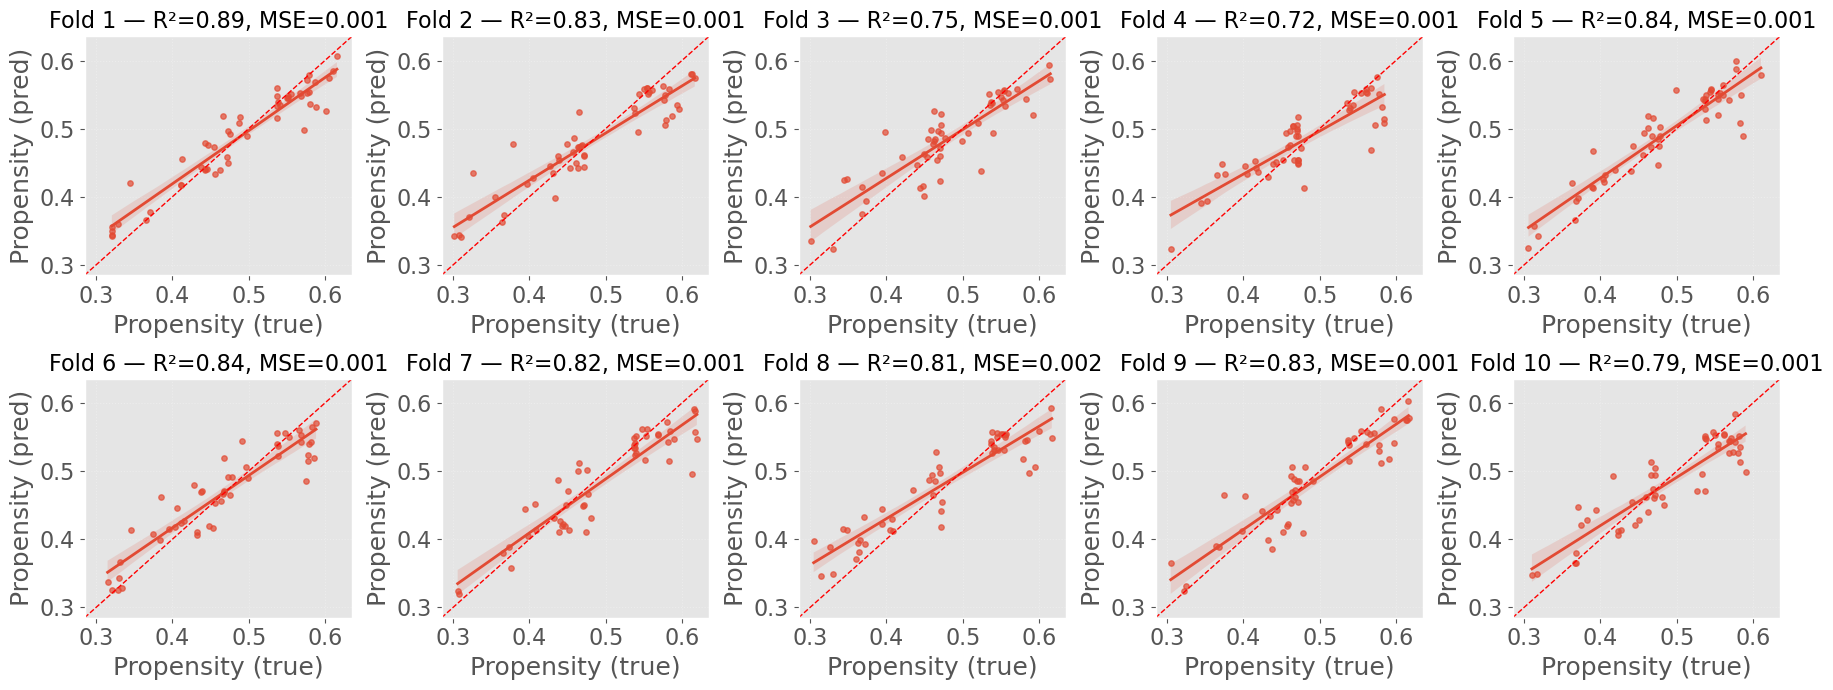

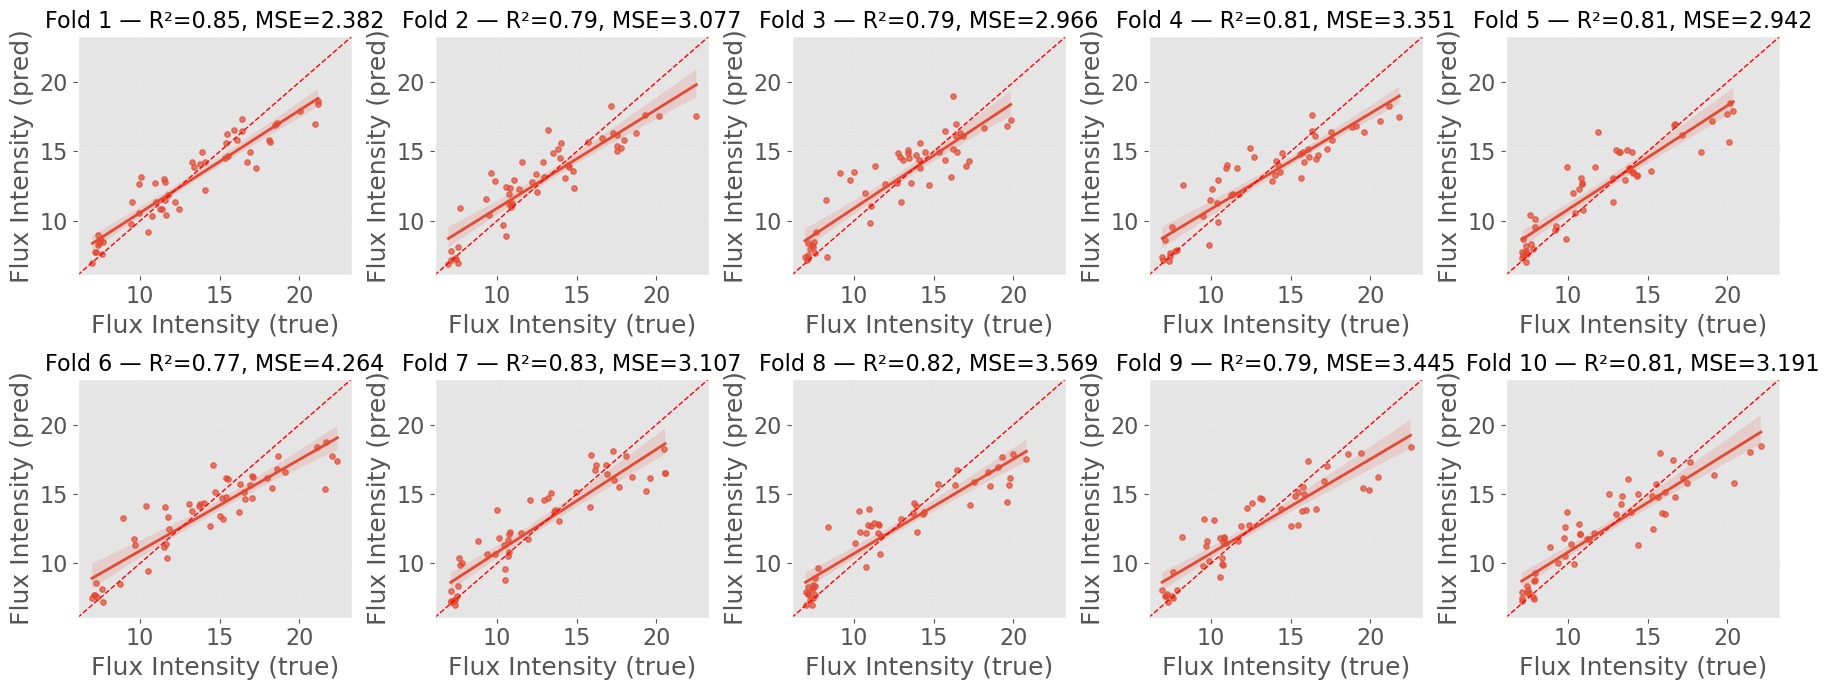

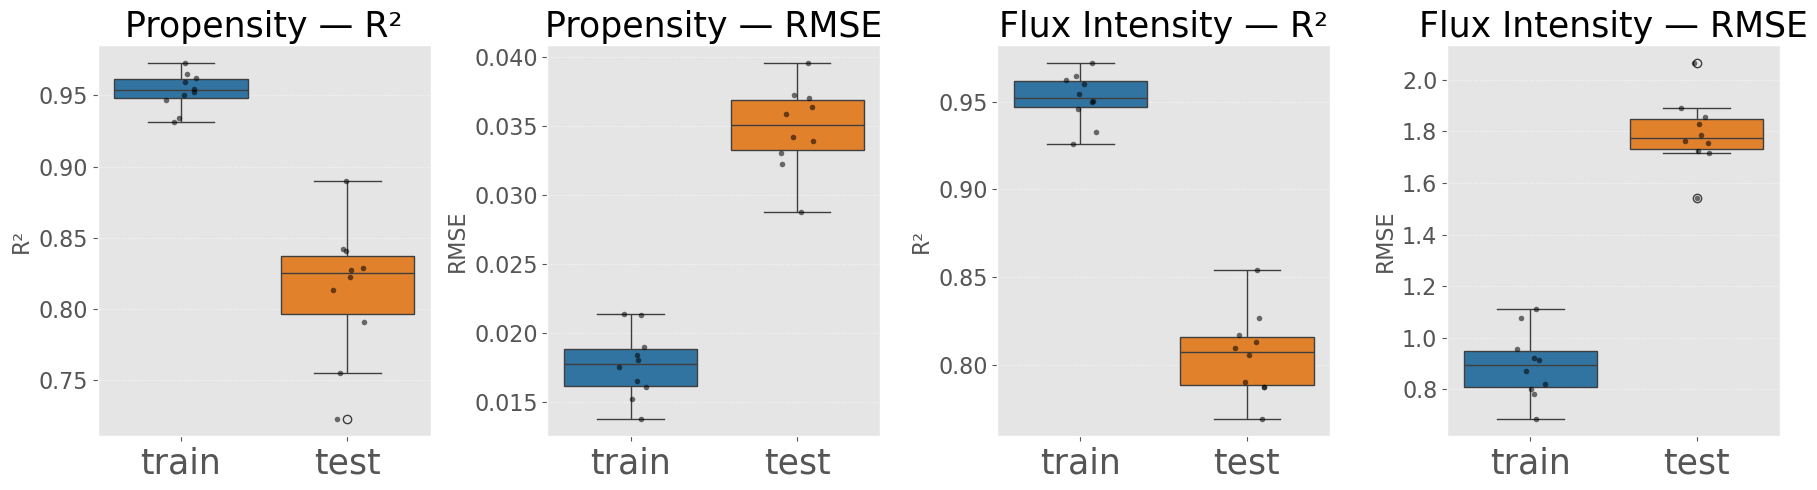

In [17]:
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_6")  
PLOTS_DIR = OUTDIR / 'performance_plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LABELS = {'A': 'Propensity', 'B': 'Flux Intensity', 'avg': 'Average'}

preds_test = load_predictions_by_fold(OUTDIR, which='test')

figA = plot_reg_per_fold(preds_test, target='A', cols=5, figsize=(18, 7),
                         target_names=TARGET_LABELS, target_index_map={'A': 0, 'B': 1})
figB = plot_reg_per_fold(preds_test, target='B', cols=5, figsize=(18, 7),
                         target_names=TARGET_LABELS, target_index_map={'A': 0, 'B': 1})

figA.savefig(PLOTS_DIR / 'regplot_per_fold_Propensity.png', dpi=600, bbox_inches='tight')
figB.savefig(PLOTS_DIR / 'regplot_per_fold_FluxIntensity.png', dpi=600, bbox_inches='tight')

#_ = build_metrics_all_folds(OUTDIR, targets_idx=(0, 1), target_labels=('A', 'B'))

fig_box = plot_box_train_test_metrics_per_target(
    OUTDIR,
    targets=('A', 'B'),
    target_names={'A': 'Propensity', 'B': 'Flux Intensity'},
    figsize=(18, 5)
)
fig_box.savefig(PLOTS_DIR / 'boxplots_by_target_r2_rmse.png', dpi=600, bbox_inches='tight')

plt.show()

### Extract importance

#### Extract Coef

In [127]:
def extract_importance_weight_fallback(pipe, module_names, importance_type_preferred='gain'):
    """
    Estrae importanza dei moduli, provando gain → weight → feature_importances_,
    e ritorna (imp_dict, type_used) dove type_used è il tipo di importance usato.
    """
    model = pipe.named_steps['model']
    imp = {m: 0.0 for m in module_names}

    try:
        booster = model.get_booster()
    except Exception as e:
        print("[Warn] model.get_booster() failed:", e)
        # fallback su feature_importances_
        try:
            fi = model.feature_importances_
            for i, m in enumerate(module_names):
                if i < len(fi):
                    imp[m] = float(fi[i])
            return imp, 'feature_importances_'
        except Exception as e2:
            print("[Warn] fallback feature_importances_ failed:", e2)
            return imp, 'none'

    # Tenta preferred
    score_dict = None
    type_used = None
    try:
        score_dict = booster.get_score(importance_type=importance_type_preferred)
    except Exception as e:
        print(f"[Warn] get_score({importance_type_preferred}) failed:", e)

    # Se score_dict è vuoto o None, prova weight
    if not score_dict:
        try:
            score_dict = booster.get_score(importance_type='weight')
            type_used = 'weight'
        except Exception as e2:
            print("[Warn] get_score(weight) also failed:", e2)
            traceback.print_exc()
            score_dict = {}

    else:
        # se preferito ha funzionato (non vuoto)
        type_used = importance_type_preferred

    # Se abbiamo un dict con dati
    if score_dict:
        # controllo se chiavi tipo "f0","f1",…
        all_f_keys = all(str(k).startswith('f') for k in score_dict.keys())
        if all_f_keys:
            for i, mod in enumerate(module_names):
                key = f"f{i}"
                imp[mod] = float(score_dict.get(key, 0.0))
        else:
            for mod in module_names:
                imp[mod] = float(score_dict.get(mod, 0.0))
    else:
        # fallback su feature_importances_
        try:
            fi = model.feature_importances_
            for i, m in enumerate(module_names):
                if i < len(fi):
                    imp[m] = float(fi[i])
            type_used = 'feature_importances_'
        except Exception as e3:
            print("[Warn] fallback feature_importances_ (final) failed:", e3)
            if type_used is None:
                type_used = 'none'

    if type_used is None:
        type_used = 'none'

    return imp, type_used

def extract_importance(
    model_dir: Path,
    outdir: Path,
    prefix: str = "pipeline_fold_",
    suffix: str = ".joblib",
    preferred_type: str = "gain"
):
    """
    Versione che salva file nominati in base al metodo di importance usato:
       importance_{type_used}_fold_{k}.csv
    """
    outdir.mkdir(parents=True, exist_ok=True)
    model_files = list(model_dir.glob(f"{prefix}*{suffix}"))
    for mf in model_files:
        m = re.search(rf"{re.escape(prefix)}(\d+){re.escape(suffix)}", mf.name)
        if not m:
            continue
        fold_id = int(m.group(1))
        pipe = joblib.load(mf)
        agg = pipe.named_steps['agg']
        module_names = agg.get_feature_names_out()

        imp_dict, type_used = extract_importance_weight_fallback(pipe, module_names, importance_type_preferred=preferred_type)

        rows = [{'module': mod, 'importance': imp_dict[mod]} for mod in module_names]
        df = pd.DataFrame(rows).sort_values(by="importance", ascending=False)

        out_csv = outdir / f"importance_{type_used}_fold_{fold_id}.csv"
        df.to_csv(out_csv, index=False)
        print(f"Saved importance (type={type_used}) for fold {fold_id} to {out_csv}")

    print("Done extracting importances for all folds.")

In [6]:
OUTDIR = Path("../data/ml_output/mt_xgb_results_test_6")

In [129]:
extract_importance(
    model_dir=OUTDIR,
    outdir=OUTDIR,
    prefix="pipeline_fold_",
    suffix=".joblib",
    preferred_type="weight"
)

Saved importance (type=weight) for fold 1 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_1.csv
Saved importance (type=weight) for fold 10 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_10.csv
Saved importance (type=weight) for fold 2 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_2.csv
Saved importance (type=weight) for fold 3 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_3.csv
Saved importance (type=weight) for fold 4 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_4.csv
Saved importance (type=weight) for fold 5 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_5.csv
Saved importance (type=weight) for fold 6 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_6.csv
Saved importance (type=weight) for fold 7 to ..\data\ml_output\mt_xgb_results_test_6\importance_weight_fold_7.csv
Saved importance (type=weight) for fold 8 to ..\data\ml_output\mt_xgb_results_test_6\i

#### Establish Threshold

In [4]:
from kneed import KneeLocator

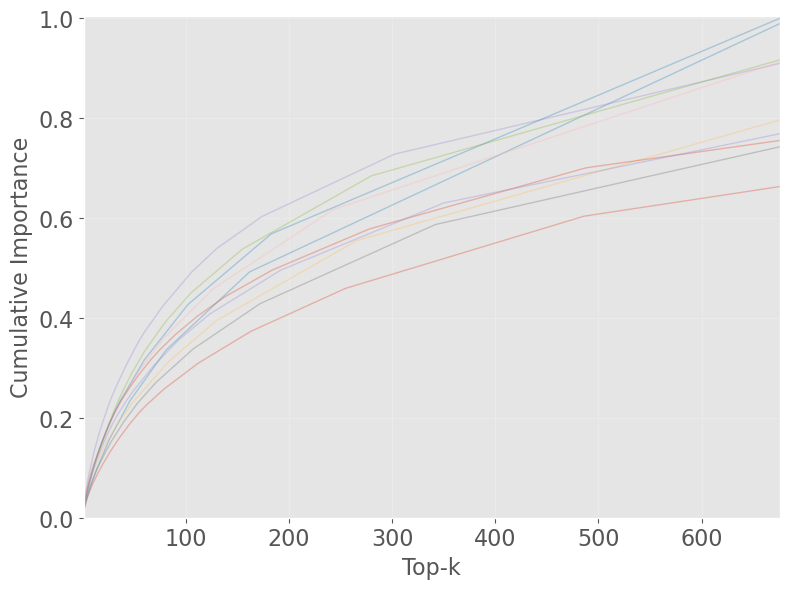

In [7]:
PLOTS_DIR = OUTDIR / "performance_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Priority order if multiple importance types exist for the same fold
priority = {"weight": 3, "gain": 2, "feature_importances_": 1, "none": 0}

#  Collect available importance files 
imp_files_by_fold = {}  # fold_id -> (path, importance_type)
for fp in OUTDIR.glob("importance_*_fold_*.csv"):
    m = re.match(r"importance_([^_]+)_fold_(\d+)\.csv$", fp.name)
    if not m:
        continue
    imp_type = m.group(1)
    fold_id = int(m.group(2))
    prev = imp_files_by_fold.get(fold_id)
    # Keep the file with higher priority
    if (prev is None) or (priority.get(imp_type, 0) > priority.get(prev[1], 0)):
        imp_files_by_fold[fold_id] = (fp, imp_type)

assert imp_files_by_fold, f"No XGBoost importance files found in {OUTDIR}"

# Build cumulative-importance curves per fold
curves = []
fold_labels = []
for fold_id, (fp, imp_type) in sorted(imp_files_by_fold.items()):
    df = pd.read_csv(fp)
    if "importance" not in df.columns:
        raise ValueError(f"{fp.name}: missing 'importance' column.")

    # Convert to float and replace NaN with zeros
    w = df["importance"].to_numpy(dtype=float)
    w = np.nan_to_num(np.maximum(w, 0.0))

    # Discard zero-importance modules before normalization
    nonzero_mask = w > 0
    if not np.any(nonzero_mask):
        print(f"[Warning] Fold {fold_id} has all-zero importances; skipping.")
        continue
    w = w[nonzero_mask]

    # Normalize so that total importance = 1
    s = w.sum()
    if s > 0:
        w = w / s

    # Sort descending and compute cumulative sum
    w_sorted = np.sort(w)[::-1]
    csum = np.cumsum(w_sorted)
    curves.append(csum)
    fold_labels.append((fold_id, imp_type, len(w)))

# --- Align curves by the minimum length for visualization ---
nmin = min(map(len, curves))
x = np.arange(1, nmin + 1)

# --- Plot all folds ---
fig, ax = plt.subplots(figsize=(8, 6))
for (fold_id, imp_type, nfeat), c in zip(fold_labels, curves):
    ax.plot(x, c[:nmin], lw=1, alpha=0.35)

ax.set_ylim(0, 1.005)
ax.set_xlim(1, nmin)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xlabel("Top-k", fontsize=16)
ax.set_ylabel("Cumulative Importance", fontsize=16)
ax.grid(True, alpha=0.2)
fig.tight_layout()

# --- Save plot ---
out_plot = PLOTS_DIR / "cumulative_importance_folds_xgb.png"
fig.savefig(out_plot, dpi=300, bbox_inches="tight")
plt.show()



Kneedle per fold (knee_k & threshold):
 fold importance_type  n_features_after_zero_filter  knee_k  knee_threshold
    1          weight                          1754     372        0.532354
    2          weight                           687     152        0.472921
    3          weight                           862     190        0.618677
    4          weight                          1228     275        0.524476
    5          weight                          1022     228        0.510300
    6          weight                           818     194        0.583578
    7          weight                           804     191        0.546075
    8          weight                          1516     300        0.590909
    9          weight                           676     158        0.524518
   10          weight                          1219     257        0.550873

Saved summary: ..\data\ml_output\mt_xgb_results_test_6\xgb_kneedle_folds_summary.csv


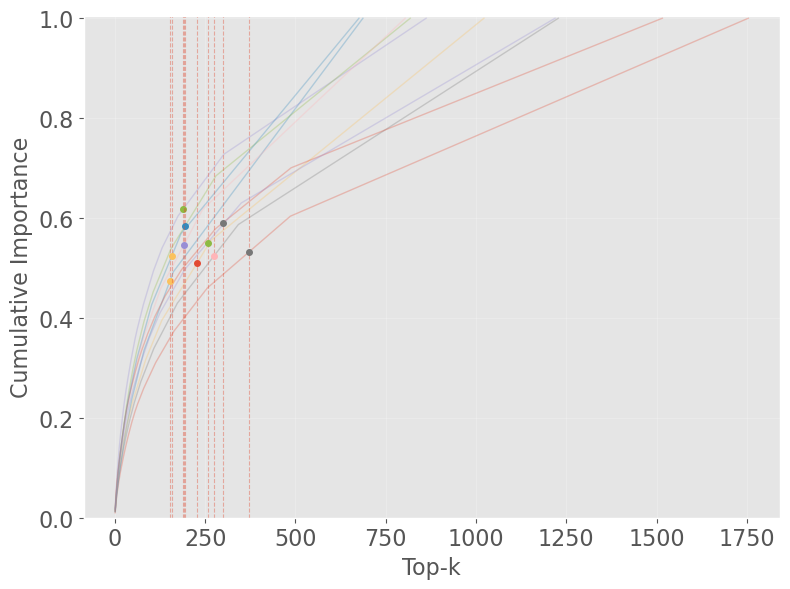

Saved knee overlay plot: ..\data\ml_output\mt_xgb_results_test_6\performance_plots\cumulative_importance_knee_overlay_xgb.png


In [8]:

KNEED_PARAMS = dict(
    curve="concave", # cumulative curves are typically concave and increasing
    direction="increasing",
    S= 5,  # sensitivity; increase (e.g., 3–10) for more conservative knees
    online=True,   
    interp_method="polynomial",
    polynomial_degree=7,
)

knee_rows = []
knee_xs = []   
knee_ys = []

# Use each fold's FULL curve 
for (fold_id, imp_type, nfeat), csum in zip(fold_labels, curves):
    x_full = np.arange(1, len(csum) + 1, dtype=float)
    y_full = csum.astype(float)

    # Normalize to [0,1]
    x_norm = (x_full - x_full.min()) / (x_full.max() - x_full.min())
    y_norm = y_full / y_full.max() if y_full.max() > 0 else y_full

    # Try Kneedle first
    knee_x = None
    knee_y = None
    try:
        kl = KneeLocator(x_full, y_full, **KNEED_PARAMS)
        if kl.knee is not None:
            knee_x = float(kl.knee)
            knee_y = float(kl.knee_y)
        else:
            # Fallback: argmax of (y_norm - x_norm) (classic “max distance to diagonal”)
            diff = y_norm - x_norm
            ki = int(np.argmax(diff))
            knee_x = float(x_full[ki])
            knee_y = float(y_full[ki])
    except Exception as e:
        # Robust fallback if kneed fails
        diff = y_norm - x_norm
        ki = int(np.argmax(diff))
        knee_x = float(x_full[ki])
        knee_y = float(y_full[ki])

    # Convert knee_x (which is 1-based along sorted features) to integer k
    k_opt = int(round(knee_x))
    k_opt = max(1, min(k_opt, len(csum)))  # clamp to valid range
    thr_opt = float(y_full[k_opt - 1] / y_full[-1])  # normalized threshold at knee

    knee_rows.append({
        "fold": fold_id,
        "importance_type": imp_type,
        "n_features_after_zero_filter": nfeat,
        "knee_k": k_opt,                    # top-k at the knee
        "knee_threshold": thr_opt,          # cumulative-importance threshold at the knee (0..1)
        "knee_x_raw": knee_x,               # raw (float) knee location
        "knee_y_raw": knee_y,               # raw cumulative value at knee
    })
    knee_xs.append(k_opt)
    knee_ys.append(y_full[k_opt - 1])

knee_df = pd.DataFrame(knee_rows).sort_values("fold")
knee_csv = OUTDIR / "xgb_kneedle_folds_summary.csv"
knee_df.to_csv(knee_csv, index=False)

print("\nKneedle per fold (knee_k & threshold):")
print(knee_df[["fold", "importance_type", "n_features_after_zero_filter", "knee_k", "knee_threshold"]].to_string(index=False))
print(f"\nSaved summary: {knee_csv}")

try:
    fig_knee, ax_knee = plt.subplots(figsize=(8, 6))
    # Re-plot all curves (aligned to each curve's own length)
    for (fold_id, imp_type, nfeat), csum in zip(fold_labels, curves):
        x_full = np.arange(1, len(csum) + 1, dtype=float)
        ax_knee.plot(x_full, csum, lw=1, alpha=0.3)

    # Draw knee verticals + points
    for (fold_id, _, _), kx, ky in zip(fold_labels, knee_xs, knee_ys):
        ax_knee.axvline(kx, ls="--", lw=0.8, alpha=0.4)
        ax_knee.plot([kx], [ky], "o", ms=4)

    ax_knee.set_xlabel("Top-k", fontsize=16)
    ax_knee.set_ylabel("Cumulative Importance", fontsize=16)
    ax_knee.tick_params(axis='x', labelsize=16)
    ax_knee.tick_params(axis='y', labelsize=16)
    ax_knee.set_ylim(0, 1.005)
    ax_knee.grid(True, alpha=0.2)
    fig_knee.tight_layout()
    out_knee_plot = PLOTS_DIR / "cumulative_importance_knee_overlay_xgb.png"
    fig_knee.savefig(out_knee_plot, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved knee overlay plot: {out_knee_plot}")
except Exception as e:
    print("[Warn] Knee overlay plot failed:", e)


In [ ]:
def _discover_fold_importance_files(outdir: Path):
    """
    Find per-fold XGBoost importance CSVs.
    Pattern: importance_{type}_fold_{k}.csv
    If multiple types for the same fold exist, keep highest priority:
      weight > gain > feature_importances_ > none
    Returns: dict {fold_id (int): (Path, importance_type:str)}
    """
    outdir = Path(outdir)
    priority = {"weight": 3, "gain": 2, "feature_importances_": 1, "none": 0}
    found = {}
    for fp in outdir.glob("importance_*_fold_*.csv"):
        m = re.match(r"importance_([^_]+)_fold_(\d+)\.csv$", fp.name)
        if not m:
            continue
        imp_type = m.group(1)
        fold_id = int(m.group(2))
        prev = found.get(fold_id)
        if (prev is None) or (priority.get(imp_type, 0) > priority.get(prev[1], 0)):
            found[fold_id] = (fp, imp_type)
    return dict(sorted(found.items()))

def _read_importance_table(fp: Path):
    """
    Robust reader for importance CSV produced by extract_importance().
    Expected columns: ['module','importance'] or ['gene','importance'].
    Some variants may have saved with/without index; we normalize.
    Returns a DataFrame with columns: ['feature','importance'] and dtype float.
    """
    df = pd.read_csv(fp)
    cols = set(df.columns.str.lower())
    if "importance" not in cols:
        raise ValueError(f"{fp.name}: missing 'importance' column.")

    # Try to find the feature-name column
    feat_col = None
    for cand in ["module", "gene", "feature", "name"]:
        if cand in df.columns:
            feat_col = cand
            break

    if feat_col is None:
        # If no explicit column, assume first column is feature names
        # (this shouldn't happen because we wrote index=False, but keep it robust)
        feat_col = df.columns[0]

    df2 = df[[feat_col, "importance"]].copy()
    df2.columns = ["feature", "importance"]
    df2["feature"] = df2["feature"].astype(str)
    df2["importance"] = pd.to_numeric(df2["importance"], errors="coerce").fillna(0.0).astype(float)
    return df2

def _knee_from_cumulative(csum: np.ndarray, kneed_params: dict):
    """
    Compute knee (top-k) on a single cumulative-importance curve.
    Returns (k_opt:int, thr_opt:float). Robust fallback = argmax(y_norm - x_norm).
    """
    x_full = np.arange(1, len(csum) + 1, dtype=float)
    y_full = csum.astype(float)

    # Normalize for fallback & Kneedle stability
    x_norm = (x_full - x_full.min()) / (x_full.max() - x_full.min())
    y_norm = y_full / (y_full.max() if y_full.max() > 0 else 1.0)

    try:
        kl = KneeLocator(x_full, y_full, **kneed_params)
        if kl.knee is not None:
            knee_x = float(kl.knee)
        else:
            # fallback: maximum vertical distance from diagonal
            diff = y_norm - x_norm
            knee_x = float(x_full[int(np.argmax(diff))])
    except Exception:
        diff = y_norm - x_norm
        knee_x = float(x_full[int(np.argmax(diff))])

    k_opt = int(round(knee_x))
    k_opt = max(1, min(k_opt, len(csum)))  # clamp
    thr_opt = float(y_full[k_opt - 1] / y_full[-1]) if y_full[-1] > 0 else 0.0
    return k_opt, thr_opt

def _load_knees_if_available(outdir: Path):
    """
    Try to load precomputed knees from xgb_kneedle_folds_summary.csv.
    Returns dict fold -> knee_k, or {} if file not found.
    """
    knee_csv = Path(outdir) / "xgb_kneedle_folds_summary.csv"
    if not knee_csv.exists():
        return {}
    knee_df = pd.read_csv(knee_csv)
    if not {"fold", "knee_k"}.issubset(knee_df.columns):
        return {}
    return {int(r["fold"]): int(r["knee_k"]) for _, r in knee_df.iterrows()}

def compute_gene_and_module_stability_xgb(
    outdir,
    modules: dict,
    kneed_params: dict = None,
    use_precomputed_knees: bool = True,
    save_outputs: bool = True,
    genes_colname: str = "genes",
    sep: str = ";",
    module_from_gene_threshold: float | None = None,
    save_raw_outputs: bool = True,
    keep_unknown_in_raw: bool = False,
):
    """
    Compute stability at both GENE- and MODULE-level from per-fold XGBoost importance CSVs,
    using a MIXED input of modules and genes per fold.

    Args
    ----
    outdir : str | Path
        Folder with importance files importance_{type}_fold_{k}.csv
    modules : dict
        Mapping {module_name: [gene1, gene2, ...]} used during training.
    kneed_params : dict
        Parameters for KneeLocator. If None, sensible defaults are used.
    use_precomputed_knees : bool
        If True, use xgb_kneedle_folds_summary.csv when available; otherwise compute knees on the fly.
    save_outputs : bool
        If True, writes:
          - raw_selection_matrix.csv (if save_raw_outputs=True)
          - gene_selection_matrix.csv
          - gene_stability_scores.csv
          - module_selection_matrix.csv
          - module_stability_scores.csv (with a column listing genes)
    genes_colname : str
        Column name used in module stability output to list member genes.
    sep : str
        Separator used to join gene names in the module stability table.
    module_from_gene_threshold : float | None
        If None: a module is selected if it contains ANY selected gene.
        If float in [0,1]: a module is selected if
            (# selected genes in module) / (# genes in module) >= threshold.
    save_raw_outputs : bool
        If True, saves the raw mixed selection matrix (features x folds).
    keep_unknown_in_raw : bool
        If True, keep unknown features (not in modules nor in gene universe) in the RAW matrix.

    Returns
    -------
    gene_sel : DataFrame (genes × folds) with 0/1
    gene_stab: DataFrame with ['gene','n_selected','n_folds','stability']
    mod_sel  : DataFrame (modules × folds) with 0/1
    mod_stab : DataFrame with ['module','n_genes','n_selected','n_folds','stability', genes_colname]
    """
    from pathlib import Path
    import numpy as np
    import pandas as pd

    outdir = Path(outdir)
    imp_files = _discover_fold_importance_files(outdir)
    if not imp_files:
        raise FileNotFoundError(f"No XGBoost importance files found in {outdir}")

    folds = sorted(imp_files.keys())

    # --- Normalize module->genes map (deduplicate & sort) ---
    mod2genes = {m: sorted(set(gs)) for m, gs in modules.items()}

    # Universes are forced by the provided mapping to keep cross-level coherence
    all_mods  = sorted(mod2genes.keys())
    all_genes = sorted({g for gs in mod2genes.values() for g in gs})
    # Feature universe (for RAW). Unknown features are optionally allowed.
    known_feats = set(all_mods) | set(all_genes)

    # --- Prepare selection matrices ---
    gene_sel = pd.DataFrame(0, index=all_genes, columns=[f"fold_{k}" for k in folds], dtype=int)
    mod_sel  = pd.DataFrame(0, index=all_mods,  columns=[f"fold_{k}" for k in folds], dtype=int)
    # RAW (mixed): index may include unknown features if keep_unknown_in_raw=True
    raw_index = sorted(known_feats)  # start with known
    raw_sel   = pd.DataFrame(0, index=raw_index, columns=[f"fold_{k}" for k in folds], dtype=int)

    # --- Precomputed knees (optional) ---
    fold_to_knee = _load_knees_if_available(outdir) if use_precomputed_knees else {}

    # --- Default Kneedle params for cumulative-importance (concave increasing) ---
    if kneed_params is None:
        kneed_params = dict(
            curve="concave",
            direction="increasing",
            S=5.0,
            online=True,
            interp_method="polynomial",
            polynomial_degree=7,
        )

    # --- Iterate folds ---
    for k in folds:
        fp, imp_type = imp_files[k]
        tab = _read_importance_table(fp)

        # Keep strictly positive importances, sort descending
        df_pos = tab[tab["importance"] > 0.0].copy()
        if df_pos.empty:
            # nothing selected in this fold
            continue
        df_pos.sort_values("importance", ascending=False, inplace=True)

        # Normalize to compute cumulative importance and knee
        w = df_pos["importance"].to_numpy(dtype=float)
        w = np.nan_to_num(np.maximum(w, 0.0))
        if w.sum() > 0:
            w = w / w.sum()
        csum = np.cumsum(w)

        # Determine knee top-k
        if k in fold_to_knee:
            k_opt = int(fold_to_knee[k])
            k_opt = max(1, min(k_opt, len(csum)))
        else:
            k_opt, _ = _knee_from_cumulative(csum, kneed_params)

        # --- 1) RAW MIXED SELECTION ---
        selected_feats_all = list(df_pos["feature"].iloc[:k_opt])
        col = f"fold_{k}"

        if keep_unknown_in_raw:
            # Extend RAW index with any unseen unknown feature (to keep full traceability)
            new_unknowns = [f for f in selected_feats_all if f not in raw_sel.index and f not in known_feats]
            if new_unknowns:
                # append deterministically in sorted order for reproducibility
                add = sorted(new_unknowns)
                raw_sel = pd.concat([raw_sel, pd.DataFrame(0, index=add, columns=raw_sel.columns, dtype=int)], axis=0)

        # Determine which of the selected are known (for downstream module/gene logic)
        selected_feats_known = set(f for f in selected_feats_all if (keep_unknown_in_raw or f in known_feats))
        # Mark RAW = 1 for all selected (known + optionally unknown)
        for f in selected_feats_all:
            if (keep_unknown_in_raw and f in raw_sel.index) or (not keep_unknown_in_raw and f in known_feats):
                raw_sel.loc[f, col] = 1

        # --- 2) MODULE-LEVEL OUTPUT ---
        # Split raw into directly-selected modules and directly-selected genes (only among known)
        selected_modules_direct = {f for f in selected_feats_known if f in mod2genes}
        selected_genes_direct   = {f for f in selected_feats_known if f in all_genes}

        # Gene -> Module activation:
        #   - ANY (threshold=None): module is selected if it contains >=1 selected gene
        #   - Threshold (float): module is selected if fraction >= threshold
        modules_from_genes = set()
        if module_from_gene_threshold is None:
            # ANY gene activates
            for m, gs in mod2genes.items():
                if set(gs) & selected_genes_direct:
                    modules_from_genes.add(m)
        else:
            tau = float(module_from_gene_threshold)
            assert 0.0 <= tau <= 1.0, "module_from_gene_threshold must be in [0, 1]"
            for m, gs in mod2genes.items():
                if not gs:
                    continue
                frac = len(set(gs) & selected_genes_direct) / len(gs)
                if frac >= tau:
                    modules_from_genes.add(m)

        selected_modules_final = (selected_modules_direct | modules_from_genes) & set(all_mods)
        if selected_modules_final:
            mod_sel.loc[list(selected_modules_final), col] = 1

        # --- 3) GENE-LEVEL OUTPUT (EXPAND MODULES -> GENES) ---
        genes_from_modules = {g for m in selected_modules_final for g in mod2genes.get(m, [])}
        selected_genes_final = genes_from_modules & set(all_genes)
        if selected_genes_final:
            gene_sel.loc[list(selected_genes_final), col] = 1

    # --- Stability summaries ---
    n_f = len(folds)

    gene_nsel = gene_sel.sum(axis=1)
    gene_stab = (
        pd.DataFrame({
            "gene": gene_sel.index,
            "n_selected": gene_nsel.values,
            "n_folds": n_f,
            "stability": (gene_nsel / n_f).values
        })
        .query("n_selected > 0")
        .sort_values(["stability", "n_selected", "gene"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    mod_nsel = mod_sel.sum(axis=1)
    mod_genes_col = [sep.join(sorted(mod2genes.get(m, []))) for m in mod_sel.index]
    mod_stab = (
        pd.DataFrame({
            "module": mod_sel.index,
            "n_genes": [len(mod2genes.get(m, [])) for m in mod_sel.index],
            "n_selected": mod_nsel.values,
            "n_folds": n_f,
            "stability": (mod_nsel / n_f).values,
            genes_colname: mod_genes_col
        })
        .query("n_selected > 0")
        .sort_values(["stability", "n_selected", "module"], ascending=[False, False, True])
        .reset_index(drop=True)
    )

    # --- Save outputs ---
    if save_outputs:
        if save_raw_outputs:
            raw_sel.to_csv(outdir / "raw_selection_matrix.csv", index=True)
        gene_sel.to_csv(outdir / "gene_selection_matrix.csv", index=True)
        gene_stab.to_csv(outdir / "gene_stability_scores.csv", index=False)
        mod_sel.to_csv(outdir / "module_selection_matrix.csv", index=True)
        mod_stab.to_csv(outdir / "module_stability_scores.csv", index=False)

    return gene_sel, gene_stab, mod_sel, mod_stab


In [13]:
gene_sel, gene_stab, mod_sel, mod_stab = compute_gene_and_module_stability_xgb(
    outdir=OUTDIR,
    modules=modules,
    use_precomputed_knees=True,  
    kneed_params=dict(
        curve="concave", direction="increasing",
        S=5.0, online=True,
        interp_method="polynomial", polynomial_degree=7
    ),
    save_outputs=True,
    sep="\n"
)


In [14]:
gene_stab["stability"].value_counts().sort_index(ascending=False)

stability
1.0    106
0.9     17
0.8     21
0.7     42
0.6     37
0.5     34
0.4     85
0.3     69
0.2    168
0.1    574
Name: count, dtype: int64

### Ablation

##### Ablation across all folds (mean label A and B)


In [ ]:
from typing import Sequence, Dict, Any, Optional
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
import math

# helpers
def r2_macro(y_true, y_pred):
    if y_true.ndim == 1:
        return float(r2_score(y_true, y_pred))
    vals = [r2_score(y_true[:, j], y_pred[:, j]) for j in range(y_true.shape[1])]
    return float(np.mean(vals))

def rmse_macro(y_true, y_pred):
    if y_true.ndim == 1:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))
    vals = [np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])) for j in range(y_true.shape[1])]
    return float(np.mean(vals))

# load best params (prefers 'model__' keys; falls back to plain) 
def load_best_params_for_folds_xgb(metadata_dir: Path) -> Dict[int, Dict[str, Any]]:
    """
    Raccoglie i best_params per ogni fold dai metadata prodotti da nested_cv_xgb_phase1.
    Preferisce i 'best_params' (con prefisso 'model__'); se non esistono, aggiunge il prefisso a 'best_params_plain'.
    Supporta sia file in root tipo metadata_fold_XX.json che in sottocartelle fold_XX/.
    """
    params_by_fold: Dict[int, Dict[str, Any]] = {}

    # 1) root: metadata_fold_*.json
    for p in metadata_dir.glob("metadata_fold_*.json"):
        try:
            fold = int(p.stem.split("_")[-1])
        except Exception:
            continue
        with open(p, "r") as f:
            meta = json.load(f)
        best = meta.get("best_params", {})
        if not best:
            # fallback: plain -> prefissati
            plain = meta.get("best_params_plain", {})
            best = {f"model__{k}": v for k, v in plain.items()}
        if best:
            params_by_fold[fold] = best

    for p in metadata_dir.glob("fold_*"):
        if not p.is_dir():
            continue
        try:
            fold = int(p.name.split("_")[-1])
        except Exception:
            continue
        cand1 = p / f"metadata_fold_{fold:02d}.json"
        cand2 = p / "metadata.json"
        target = cand1 if cand1.exists() else (cand2 if cand2.exists() else None)
        if target is None:
            continue
        with open(target, "r") as f:
            meta = json.load(f)
        best = meta.get("best_params", {})
        if not best:
            plain = meta.get("best_params_plain", {})
            best = {f"model__{k}": v for k, v in plain.items()}
        if best:
            params_by_fold[fold] = best  # sovrascrive eventuali root

    if not params_by_fold:
        raise RuntimeError(f"Nessun metadata XGB trovato in {metadata_dir}")
    return params_by_fold

def _xgb_ablation_task(
    fold_id: int,
    frac: float,
    r: int,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    modules: dict,
    best_params: Dict[str, Any],
    make_pipeline_fn,
    seed: int,
    feature_names: Sequence[str],
):
    """
    Ogni job sottocampiona il TRAIN del fold (fraqzione 'frac'), fitta con i best params del fold
    (niente oggetti condivisi), scala Y come nel training, predice su TRAIN_sub e TEST,
    e ritorna metriche macro (R2/RMSE).
    """
    rng = np.random.default_rng(seed + 1000 * fold_id + 13 * int(round(frac*1000)) + r)

    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # subset di TRAIN
    n_sub = max(5, int(math.ceil(frac * len(tr_idx))))
    sub_idx_local = rng.choice(len(tr_idx), size=n_sub, replace=False)
    X_sub, y_sub = X_tr[sub_idx_local], y_tr[sub_idx_local]

    # scaling Y (coerente con nested_cv_xgb_phase1)
    y_scaler = StandardScaler()
    y_sub_z = y_scaler.fit_transform(y_sub)
    y_te_z  = y_scaler.transform(y_te)  # da usare solo se servisse confronto in z-space (qui no)

    # pipeline per questo job
    pipe = make_pipeline_fn(modules=modules, feature_names=feature_names, seed=seed)
    # forza single-thread nel model per sicurezza quando parallelo esterno
    pipe.set_params(model__n_jobs=1)
    # applica i best params (già prefissati con 'model__')
    pipe.set_params(**best_params)

    # fit su Y standardizzate
    pipe.fit(X_sub, y_sub_z)

    # predizioni -> inverti lo scaling per calcolare metriche nello spazio originale
    yhat_sub_z = pipe.predict(X_sub)
    yhat_te_z  = pipe.predict(X_te)
    yhat_sub   = y_scaler.inverse_transform(yhat_sub_z)
    yhat_te    = y_scaler.inverse_transform(yhat_te_z)

    return {
        "fold": fold_id,
        "repeat": r + 1,
        "train_frac": float(frac),
        "n_train_used": int(n_sub),
        "R2_train": r2_macro(y_sub, yhat_sub),
        "RMSE_train": rmse_macro(y_sub, yhat_sub),
        "R2_test": r2_macro(y_te, yhat_te),
        "RMSE_test": rmse_macro(y_te, yhat_te),
    }

#  run on a single fold 
def run_xgb_ablation_on_fold(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    best_params: Dict[str, Any],
    make_pipeline_fn,
    fractions: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    repeats: int = 3,
    seed: int = 42,
    fold_id: int = 1,
    outdir: Path = Path("./ablation_xgb"),
    make_plots: bool = False,
    n_jobs_inner: int = -1,
) -> pd.DataFrame:
    outdir.mkdir(parents=True, exist_ok=True)
    X = X_df.values.astype(np.float32)
    y = y_mat.astype(np.float32)
    feature_names = list(X_df.columns)

    tasks = [(frac, r) for frac in fractions for r in range(repeats)]

    with threadpool_limits(limits=1):
        rows = Parallel(n_jobs=n_jobs_inner, backend="loky", verbose=0)(
            delayed(_xgb_ablation_task)(
                fold_id, frac, r, tr_idx, te_idx, X, y,
                modules, best_params, make_pipeline_fn,
                seed, feature_names
            )
            for (frac, r) in tasks
        )

    df = pd.DataFrame(rows)
    agg = (df.groupby(["fold", "train_frac"], as_index=False)
             .agg(n_train_used=("n_train_used", "mean"),
                  R2_train_mean=("R2_train", "mean"),  R2_train_sd=("R2_train", "std"),
                  R2_test_mean=("R2_test", "mean"),    R2_test_sd=("R2_test", "std"),
                  RMSE_train_mean=("RMSE_train", "mean"), RMSE_train_sd=("RMSE_train", "std"),
                  RMSE_test_mean=("RMSE_test", "mean"),   RMSE_test_sd=("RMSE_test", "std")))

    df.to_csv(outdir / f"xgb_ablation_fold_{fold_id:02d}_raw.csv", index=False)
    agg.to_csv(outdir / f"xgb_ablation_fold_{fold_id:02d}_summary.csv", index=False)

    if make_plots:
        x = agg["train_frac"].values
        plt.figure()
        plt.title(f"XGB Ablation — Fold {fold_id} (R²)")
        plt.plot(x, agg["R2_train_mean"], marker="o", label="R² Train")
        plt.plot(x, agg["R2_test_mean"],  marker="o", label="R² Test")
        plt.xlabel("Training fraction"); plt.ylabel("R² (macro)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(outdir / f"xgb_ablation_fold_{fold_id:02d}_R2.png", dpi=160, bbox_inches="tight")
        plt.close()

        plt.figure()
        plt.title(f"XGB Ablation — Fold {fold_id} (RMSE)")
        plt.plot(x, agg["RMSE_train_mean"], marker="o", label="RMSE Train")
        plt.plot(x, agg["RMSE_test_mean"],  marker="o", label="RMSE Test")
        plt.xlabel("Training fraction"); plt.ylabel("RMSE (macro)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(outdir / f"xgb_ablation_fold_{fold_id:02d}_RMSE.png", dpi=160, bbox_inches="tight")
        plt.close()

    return agg

# run across all folds
def run_xgb_ablation_all_folds(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    outer_cv,
    metadata_dir: Path,              # es: Path("../data/ml_output/mt_xgb_results_test_6")
    make_pipeline_fn,
    fractions: Sequence[float] = (0.3, 0.5, 0.7, 0.9, 1.0),
    repeats: int = 5,
    seed: int = 42,
    outdir: Path = Path("./ablation_xgb"),
    make_plots: bool = False,
    n_jobs_outer: Optional[int] = 1,
    n_jobs_inner: Optional[int] = -1,
) -> pd.DataFrame:

    params_by_fold = load_best_params_for_folds_xgb(metadata_dir)
    X = X_df.values
    fold_iter = list(outer_cv.split(X))

    # se parallelizzi fuori, tieni il model single-thread (già fatto) e n_jobs_inner=1
    if n_jobs_outer and n_jobs_outer != 1:
        n_jobs_inner = 1
        with threadpool_limits(limits=1):
            results = Parallel(n_jobs=n_jobs_outer, backend="loky", verbose=0)(
                delayed(run_xgb_ablation_on_fold)(
                    X_df=X_df, y_mat=y_mat, modules=modules,
                    tr_idx=tr_idx, te_idx=te_idx,
                    best_params=params_by_fold.get(k+1, {}),
                    make_pipeline_fn=make_pipeline_fn,
                    fractions=fractions, repeats=repeats, seed=seed,
                    fold_id=k+1, outdir=outdir, make_plots=make_plots,
                    n_jobs_inner=n_jobs_inner
                )
                for k, (tr_idx, te_idx) in enumerate(fold_iter)
            )
        all_aggs_df = pd.concat(results, axis=0, ignore_index=True)
    else:
        all_aggs = []
        for k, (tr_idx, te_idx) in enumerate(fold_iter, start=1):
            if k not in params_by_fold:
                raise RuntimeError(f"Mancano i best_params per fold {k} in {metadata_dir}")
            agg = run_xgb_ablation_on_fold(
                X_df=X_df, y_mat=y_mat, modules=modules,
                tr_idx=tr_idx, te_idx=te_idx,
                best_params=params_by_fold[k], make_pipeline_fn=make_pipeline_fn,
                fractions=fractions, repeats=repeats, seed=seed,
                fold_id=k, outdir=outdir, make_plots=make_plots,
                n_jobs_inner=n_jobs_inner
            )
            all_aggs.append(agg)
        all_aggs_df = pd.concat(all_aggs, axis=0, ignore_index=True)

    all_aggs_df.to_csv(outdir / "xgb_ablation_all_folds_summary.csv", index=False)
    return all_aggs_df

# aggregated plots
def plot_xgb_ablation_summary(summary_csv: Path, outdir: Optional[Path] = None):
    df = pd.read_csv(summary_csv)
    if "train_frac" not in df.columns:
        raise ValueError(f"{summary_csv} manca la colonna 'train_frac'.")

    grouped = (
        df.groupby("train_frac", as_index=False)
          .agg(
              R2_train_mean=("R2_train_mean", "mean"),
              R2_train_sd=("R2_train_mean", "std"),
              R2_test_mean=("R2_test_mean", "mean"),
              R2_test_sd=("R2_test_mean", "std"),
              RMSE_train_mean=("RMSE_train_mean", "mean"),
              RMSE_train_sd=("RMSE_train_mean", "std"),
              RMSE_test_mean=("RMSE_test_mean", "mean"),
              RMSE_test_sd=("RMSE_test_mean", "std"),
          )
          .sort_values("train_frac")
    )

    x = grouped["train_frac"].values
    outdir = Path(outdir) if outdir else Path(summary_csv).parent
    outdir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(7, 5))
    plt.title("Aggregated ablation (R²)")
    plt.plot(x, grouped["R2_train_mean"], "o-", label="R² Train")
    plt.fill_between(x,
        grouped["R2_train_mean"] - grouped["R2_train_sd"],
        grouped["R2_train_mean"] + grouped["R2_train_sd"],
        alpha=0.2)
    plt.plot(x, grouped["R2_test_mean"], "o-", label="R² Test")
    plt.fill_between(x,
        grouped["R2_test_mean"] - grouped["R2_test_sd"],
        grouped["R2_test_mean"] + grouped["R2_test_sd"],
        alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("R²"); plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / "xgb_ablation_all_folds_R2.png", dpi=160, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.title("Aggregated ablation (RMSE)")
    plt.plot(x, grouped["RMSE_train_mean"], "o-", label="RMSE Train")
    plt.fill_between(x,
        grouped["RMSE_train_mean"] - grouped["RMSE_train_sd"],
        grouped["RMSE_train_mean"] + grouped["RMSE_train_sd"],
        alpha=0.2)
    plt.plot(x, grouped["RMSE_test_mean"], "o-", label="RMSE Test")
    plt.fill_between(x,
        grouped["RMSE_test_mean"] - grouped["RMSE_test_sd"],
        grouped["RMSE_test_mean"] + grouped["RMSE_test_sd"],
        alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("RMSE"); plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / "xgb_ablation_all_folds_RMSE.png", dpi=160, bbox_inches="tight")
    plt.close()

    print(f"Plots salvati in {outdir}")


In [134]:
XGB_META_DIR = Path("../data/ml_output/mt_xgb_results_test_6")  
XGB_ABL_OUT  = XGB_META_DIR / "ablation_out"
XGB_ABL_OUT.mkdir(parents=True, exist_ok=True)

ablation_df = run_xgb_ablation_all_folds(
    X_df=X_use,
    y_mat=y,
    modules=modules,
    outer_cv=outer_cv,
    metadata_dir=XGB_META_DIR,
    make_pipeline_fn=make_pipeline_xgb,
    fractions=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    repeats=5,
    seed=SEED,
    outdir=XGB_ABL_OUT,
    make_plots=True,
    n_jobs_inner=-1, 
    n_jobs_outer=1
)

print(ablation_df.head())

plot_xgb_ablation_summary(
    summary_csv=XGB_ABL_OUT / "xgb_ablation_all_folds_summary.csv",
    outdir=XGB_ABL_OUT
)

c:\Users\LL331070\AppData\Local\anaconda3\envs\data_env\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


   fold  train_frac  n_train_used  R2_train_mean  R2_train_sd  R2_test_mean  \
0     1         0.3         139.0       0.491151     0.015274      0.332334   
1     1         0.4         185.0       0.756784     0.016722      0.595370   
2     1         0.5         231.0       0.835455     0.012986      0.707709   
3     1         0.6         277.0       0.926778     0.002679      0.761536   
4     1         0.7         323.0       0.942364     0.002268      0.816055   

   R2_test_sd  RMSE_train_mean  RMSE_train_sd  RMSE_test_mean  RMSE_test_sd  
0    0.010223         1.490001       0.017639        1.694935      0.045698  
1    0.031150         1.035935       0.022237        1.362086      0.087612  
2    0.033735         0.883900       0.032065        1.158535      0.064113  
3    0.035794         0.585977       0.014311        1.096929      0.100937  
4    0.020379         0.510023       0.017759        0.962070      0.068711  
Plots salvati in ..\data\ml_output\mt_xgb_results_test_6\

##### Ablation across all folds (sep label A and B)


In [139]:
import os, json, math
from pathlib import Path
from typing import Sequence, Dict, Any, Optional
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits

def r2_macro(y_true, y_pred):
    if y_true.ndim == 1:
        return float(r2_score(y_true, y_pred))
    vals = [r2_score(y_true[:, j], y_pred[:, j]) for j in range(y_true.shape[1])]
    return float(np.mean(vals))

def rmse_macro(y_true, y_pred):
    if y_true.ndim == 1:
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))
    vals = [np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])) for j in range(y_true.shape[1])]
    return float(np.mean(vals))

def load_best_params_for_folds_xgb(metadata_dir: Path) -> Dict[int, Dict[str, Any]]:
    """
    Raccoglie i best_params per ogni fold dai metadata prodotti da nested_cv_xgb_phase1.
    Preferisce 'best_params' (già con 'model__'); fallback su 'best_params_plain' con prefisso aggiunto.
    Supporta sia file in root tipo metadata_fold_XX.json che in sottocartelle fold_XX/.
    """
    params_by_fold: Dict[int, Dict[str, Any]] = {}

    # root: metadata_fold_*.json
    for p in metadata_dir.glob("metadata_fold_*.json"):
        try:
            fold = int(p.stem.split("_")[-1])
        except Exception:
            continue
        with open(p, "r") as f:
            meta = json.load(f)
        best = meta.get("best_params", {})
        if not best:
            plain = meta.get("best_params_plain", {})
            best = {f"model__{k}": v for k, v in plain.items()}
        if best:
            params_by_fold[fold] = best

    # sottocartelle: fold_XX/{metadata_fold_XX.json|metadata.json}
    for p in metadata_dir.glob("fold_*"):
        if not p.is_dir():
            continue
        try:
            fold = int(p.name.split("_")[-1])
        except Exception:
            continue
        cand1 = p / f"metadata_fold_{fold:02d}.json"
        cand2 = p / "metadata.json"
        target = cand1 if cand1.exists() else (cand2 if cand2.exists() else None)
        if target is None:
            continue
        with open(target, "r") as f:
            meta = json.load(f)
        best = meta.get("best_params", {})
        if not best:
            plain = meta.get("best_params_plain", {})
            best = {f"model__{k}": v for k, v in plain.items()}
        if best:
            params_by_fold[fold] = best  # sovrascrive eventuali root

    if not params_by_fold:
        raise RuntimeError(f"Nessun metadata XGB trovato in {metadata_dir}")
    return params_by_fold

def _xgb_ablation_task(
    fold_id: int,
    frac: float,
    r: int,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    modules: dict,
    best_params: Dict[str, Any],
    make_pipeline_fn,
    seed: int,
    feature_names: Sequence[str],
):
    """
    Sottocampiona il TRAIN (frazione 'frac'), fitta con i best params del fold,
    scala Y come nel training, predice su TRAIN_sub e TEST,
    e ritorna metriche per-target (A/B) e macro.
    """
    rng = np.random.default_rng(seed + 1000 * fold_id + 13 * int(round(frac*1000)) + r)

    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # subset di TRAIN
    n_sub = max(5, int(math.ceil(frac * len(tr_idx))))
    sub_idx_local = rng.choice(len(tr_idx), size=n_sub, replace=False)
    X_sub, y_sub = X_tr[sub_idx_local], y_tr[sub_idx_local]

    # scaling Y (coerente con nested_cv_xgb_phase1)
    y_scaler = StandardScaler()
    y_sub_z = y_scaler.fit_transform(y_sub)

    # pipeline per questo job (single-thread nel model)
    pipe = make_pipeline_fn(modules=modules, feature_names=feature_names, seed=seed)
    pipe.set_params(model__n_jobs=1, **best_params)

    # fit su Y standardizzate
    pipe.fit(X_sub, y_sub_z)

    # predizioni -> inverti lo scaling per metriche nello spazio originale
    yhat_sub = y_scaler.inverse_transform(pipe.predict(X_sub))
    yhat_te  = y_scaler.inverse_transform(pipe.predict(X_te))

    # metriche per-target
    r2_train_list, rmse_train_list = [], []
    r2_test_list,  rmse_test_list  = [], []
    T = y.shape[1]
    for j in range(T):
        r2_train_list.append(r2_score(y_sub[:, j], yhat_sub[:, j]))
        rmse_train_list.append(np.sqrt(mean_squared_error(y_sub[:, j], yhat_sub[:, j])))
        r2_test_list.append(r2_score(y_te[:, j], yhat_te[:, j]))
        rmse_test_list.append(np.sqrt(mean_squared_error(y_te[:, j], yhat_te[:, j])))

    out = {
        "fold": fold_id,
        "repeat": r + 1,
        "train_frac": float(frac),
        "n_train_used": int(n_sub),
        # macro averages
        "R2_train_macro":  float(np.mean(r2_train_list)),
        "R2_test_macro":   float(np.mean(r2_test_list)),
        "RMSE_train_macro":float(np.mean(rmse_train_list)),
        "RMSE_test_macro": float(np.mean(rmse_test_list)),
    }

    # nomi coerenti con A (0) e B (1)
    labels = ["A", "B"][:T]
    for j, lab in enumerate(labels):
        out[f"R2_train_{lab}"] = r2_train_list[j]
        out[f"R2_test_{lab}"]  = r2_test_list[j]
        out[f"RMSE_train_{lab}"] = rmse_train_list[j]
        out[f"RMSE_test_{lab}"]  = rmse_test_list[j]

    return out

def run_xgb_ablation_on_fold(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    tr_idx: np.ndarray,
    te_idx: np.ndarray,
    best_params: Dict[str, Any],
    make_pipeline_fn,
    fractions: Sequence[float] = (0.25, 0.5, 0.75, 1.0),
    repeats: int = 3,
    seed: int = 42,
    fold_id: int = 1,
    outdir: Path = Path("./ablation_xgb"),
    make_plots: bool = False,
    n_jobs_inner: int = -1,
) -> pd.DataFrame:
    outdir.mkdir(parents=True, exist_ok=True)
    X = X_df.values.astype(np.float32)
    y = y_mat.astype(np.float32)
    feature_names = list(X_df.columns)

    tasks = [(frac, r) for frac in fractions for r in range(repeats)]

    with threadpool_limits(limits=1):
        rows = Parallel(n_jobs=n_jobs_inner, backend="loky", verbose=0)(
            delayed(_xgb_ablation_task)(
                fold_id, frac, r, tr_idx, te_idx, X, y,
                modules, best_params, make_pipeline_fn,
                seed, feature_names
            )
            for (frac, r) in tasks
        )

    df = pd.DataFrame(rows)

    # aggregazione per fold e frazione (mean)
    agg = (df.groupby(["fold", "train_frac"], as_index=False)
             .agg(
                 n_train_used=("n_train_used", "mean"),
                 # macro
                 R2_train_macro=("R2_train_macro", "mean"),
                 R2_test_macro =("R2_test_macro", "mean"),
                 RMSE_train_macro=("RMSE_train_macro", "mean"),
                 RMSE_test_macro =("RMSE_test_macro", "mean"),
                 # per-target
                 R2_train_A=("R2_train_A", "mean"),
                 R2_test_A =("R2_test_A", "mean"),
                 RMSE_train_A=("RMSE_train_A", "mean"),
                 RMSE_test_A =("RMSE_test_A", "mean"),
                 R2_train_B=("R2_train_B", "mean"),
                 R2_test_B =("R2_test_B", "mean"),
                 RMSE_train_B=("RMSE_train_B", "mean"),
                 RMSE_test_B =("RMSE_test_B", "mean"),
             ))

    # salva CSV
    df.to_csv(outdir / f"xgb_ablation_fold_{fold_id:02d}_raw.csv", index=False)
    agg.to_csv(outdir / f"xgb_ablation_fold_{fold_id:02d}_summary.csv", index=False)

    # (opzionali) plot macro per fold
    if make_plots:
        x = agg["train_frac"].values
        plt.figure()
        plt.title(f"XGB Ablation — Fold {fold_id} (R² macro)")
        plt.plot(x, agg["R2_train_macro"], marker="o", label="R² Train")
        plt.plot(x, agg["R2_test_macro"],  marker="o", label="R² Test")
        plt.xlabel("Training fraction"); plt.ylabel("R² (macro)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(outdir / f"xgb_ablation_fold_{fold_id:02d}_R2_macro.png", dpi=160, bbox_inches="tight")
        plt.close()

        plt.figure()
        plt.title(f"XGB Ablation — Fold {fold_id} (RMSE macro)")
        plt.plot(x, agg["RMSE_train_macro"], marker="o", label="RMSE Train")
        plt.plot(x, agg["RMSE_test_macro"],  marker="o", label="RMSE Test")
        plt.xlabel("Training fraction"); plt.ylabel("RMSE (macro)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(outdir / f"xgb_ablation_fold_{fold_id:02d}_RMSE_macro.png", dpi=160, bbox_inches="tight")
        plt.close()

    return agg

def run_xgb_ablation_all_folds(
    X_df: pd.DataFrame,
    y_mat: np.ndarray,
    modules: dict,
    outer_cv,
    metadata_dir: Path,              # es: Path("../data/ml_output/mt_xgb_results_test_6")
    make_pipeline_fn,
    fractions: Sequence[float] = (0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    repeats: int = 5,
    seed: int = 42,
    outdir: Path = Path("./ablation_xgb"),
    make_plots: bool = False,
    n_jobs_outer: Optional[int] = 1,
    n_jobs_inner: Optional[int] = -1,
) -> pd.DataFrame:

    params_by_fold = load_best_params_for_folds_xgb(metadata_dir)
    X = X_df.values
    fold_iter = list(outer_cv.split(X))

    # se parallelizzi fuori, tieni il model single-thread (già fatto) e n_jobs_inner=1
    if n_jobs_outer and n_jobs_outer != 1:
        n_jobs_inner = 1
        with threadpool_limits(limits=1):
            results = Parallel(n_jobs=n_jobs_outer, backend="loky", verbose=0)(
                delayed(run_xgb_ablation_on_fold)(
                    X_df=X_df, y_mat=y_mat, modules=modules,
                    tr_idx=tr_idx, te_idx=te_idx,
                    best_params=params_by_fold.get(k+1, {}),
                    make_pipeline_fn=make_pipeline_fn,
                    fractions=fractions, repeats=repeats, seed=seed,
                    fold_id=k+1, outdir=outdir, make_plots=make_plots,
                    n_jobs_inner=n_jobs_inner
                )
                for k, (tr_idx, te_idx) in enumerate(fold_iter)
            )
        all_aggs_df = pd.concat(results, axis=0, ignore_index=True)
    else:
        all_aggs = []
        for k, (tr_idx, te_idx) in enumerate(fold_iter, start=1):
            if k not in params_by_fold:
                raise RuntimeError(f"Mancano i best_params per fold {k} in {metadata_dir}")
            agg = run_xgb_ablation_on_fold(
                X_df=X_df, y_mat=y_mat, modules=modules,
                tr_idx=tr_idx, te_idx=te_idx,
                best_params=params_by_fold[k], make_pipeline_fn=make_pipeline_fn,
                fractions=fractions, repeats=repeats, seed=seed,
                fold_id=k, outdir=outdir, make_plots=make_plots,
                n_jobs_inner=n_jobs_inner
            )
            all_aggs.append(agg)
        all_aggs_df = pd.concat(all_aggs, axis=0, ignore_index=True)

    all_aggs_df.to_csv(outdir / "xgb_ablation_all_folds_summary.csv", index=False)
    return all_aggs_df

def plot_xgb_ablation_summary_by_target(summary_csv: Path,
                                        outdir: Optional[Path] = None,
                                        target_names: dict = {'A': 'Propensity', 'B': 'Flux Intensity'}):
    """
    Crea 4 grafici separati (PNG):
      - R² — A, R² — B
      - RMSE — A, RMSE — B
    Ogni grafico mostra mean ± sd cross-fold per ciascuna frazione, con Train e Test.
    Richiede che summary_csv contenga colonne per-target (R2_train_A, R2_test_A, ...).
    """
    df = pd.read_csv(summary_csv)
    if "train_frac" not in df.columns:
        raise ValueError(f"{summary_csv} manca la colonna 'train_frac'.")

    # Aggrega cross-fold per frazione
    grouped = (df.groupby("train_frac", as_index=False)
                 .agg(
                     R2_train_A_mean=("R2_train_A","mean"), R2_train_A_sd=("R2_train_A","std"),
                     R2_test_A_mean =("R2_test_A","mean"),  R2_test_A_sd =("R2_test_A","std"),
                     RMSE_train_A_mean=("RMSE_train_A","mean"), RMSE_train_A_sd=("RMSE_train_A","std"),
                     RMSE_test_A_mean =("RMSE_test_A","mean"),  RMSE_test_A_sd =("RMSE_test_A","std"),

                     R2_train_B_mean=("R2_train_B","mean"), R2_train_B_sd=("R2_train_B","std"),
                     R2_test_B_mean =("R2_test_B","mean"),  R2_test_B_sd =("R2_test_B","std"),
                     RMSE_train_B_mean=("RMSE_train_B","mean"), RMSE_train_B_sd=("RMSE_train_B","std"),
                     RMSE_test_B_mean =("RMSE_test_B","mean"),  RMSE_test_B_sd =("RMSE_test_B","std"),
                 )
                 .sort_values("train_frac"))

    x = grouped["train_frac"].values
    outdir = Path(outdir) if outdir else Path(summary_csv).parent
    outdir.mkdir(parents=True, exist_ok=True)

    # ---- R2 A ----
    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (R²) — {target_names.get('A','A')}")
    plt.plot(x, grouped["R2_train_A_mean"], "o-", label="Train R²")
    plt.fill_between(x,
        grouped["R2_train_A_mean"] - grouped["R2_train_A_sd"],
        grouped["R2_train_A_mean"] + grouped["R2_train_A_sd"], alpha=0.2)
    plt.plot(x, grouped["R2_test_A_mean"], "o-", label="Test R²")
    plt.fill_between(x,
        grouped["R2_test_A_mean"] - grouped["R2_test_A_sd"],
        grouped["R2_test_A_mean"] + grouped["R2_test_A_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("R²")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "xgb_ablation_R2_A.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ---- R2 B ----
    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (R²) — {target_names.get('B','B')}")
    plt.plot(x, grouped["R2_train_B_mean"], "o-", label="Train R²")
    plt.fill_between(x,
        grouped["R2_train_B_mean"] - grouped["R2_train_B_sd"],
        grouped["R2_train_B_mean"] + grouped["R2_train_B_sd"], alpha=0.2)
    plt.plot(x, grouped["R2_test_B_mean"], "o-", label="Test R²")
    plt.fill_between(x,
        grouped["R2_test_B_mean"] - grouped["R2_test_B_sd"],
        grouped["R2_test_B_mean"] + grouped["R2_test_B_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("R²")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "xgb_ablation_R2_B.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ---- RMSE A ----
    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (RMSE) — {target_names.get('A','A')}")
    plt.plot(x, grouped["RMSE_train_A_mean"], "o-", label="Train RMSE")
    plt.fill_between(x,
        grouped["RMSE_train_A_mean"] - grouped["RMSE_train_A_sd"],
        grouped["RMSE_train_A_mean"] + grouped["RMSE_train_A_sd"], alpha=0.2)
    plt.plot(x, grouped["RMSE_test_A_mean"], "o-", label="Test RMSE")
    plt.fill_between(x,
        grouped["RMSE_test_A_mean"] - grouped["RMSE_test_A_sd"],
        grouped["RMSE_test_A_mean"] + grouped["RMSE_test_A_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("RMSE")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "xgb_ablation_RMSE_A.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ---- RMSE B ----
    plt.figure(figsize=(7,5))
    plt.title(f"Ablation (RMSE) — {target_names.get('B','B')}")
    plt.plot(x, grouped["RMSE_train_B_mean"], "o-", label="Train RMSE")
    plt.fill_between(x,
        grouped["RMSE_train_B_mean"] - grouped["RMSE_train_B_sd"],
        grouped["RMSE_train_B_mean"] + grouped["RMSE_train_B_sd"], alpha=0.2)
    plt.plot(x, grouped["RMSE_test_B_mean"], "o-", label="Test RMSE")
    plt.fill_between(x,
        grouped["RMSE_test_B_mean"] - grouped["RMSE_test_B_sd"],
        grouped["RMSE_test_B_mean"] + grouped["RMSE_test_B_sd"], alpha=0.2)
    plt.xlabel("Training fraction"); plt.ylabel("RMSE")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "xgb_ablation_RMSE_B.png", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Grafici salvati in {outdir}")


In [140]:
XGB_META_DIR = Path("../data/ml_output/mt_xgb_results_test_6")
XGB_ABL_OUT  = XGB_META_DIR / "ablation_out_labels_sep"
XGB_ABL_OUT.mkdir(parents=True, exist_ok=True)

In [141]:
ablation_df = run_xgb_ablation_all_folds(
    X_df=X_use,
    y_mat=y,
    modules=modules,
    outer_cv=outer_cv,
    metadata_dir=XGB_META_DIR,
    make_pipeline_fn=make_pipeline_xgb,
    fractions=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    repeats=5,
    seed=SEED,
    outdir=XGB_ABL_OUT,
    make_plots=False, 
    n_jobs_inner=-1,
    n_jobs_outer=1
)

print(ablation_df.head())
plot_xgb_ablation_summary_by_target(
    summary_csv=XGB_ABL_OUT / "xgb_ablation_all_folds_summary.csv",
    outdir=XGB_ABL_OUT,
    target_names={'A': 'Propensity', 'B': 'Flux Intensity'}
)

   fold  train_frac  n_train_used  R2_train_macro  R2_test_macro  \
0     1         0.3         139.0        0.491151       0.332334   
1     1         0.4         185.0        0.756784       0.595370   
2     1         0.5         231.0        0.835455       0.707709   
3     1         0.6         277.0        0.926778       0.761536   
4     1         0.7         323.0        0.942364       0.816055   

   RMSE_train_macro  RMSE_test_macro  R2_train_A  R2_test_A  RMSE_train_A  \
0          1.490001         1.694935    0.486092   0.339487      0.057607   
1          1.035935         1.362086    0.761834   0.629025      0.039312   
2          0.883900         1.158535    0.847375   0.732244      0.031882   
3          0.585977         1.096929    0.931124   0.809567      0.021617   
4          0.510023         0.962070    0.945181   0.851848      0.019146   

   RMSE_test_A  R2_train_B  R2_test_B  RMSE_train_B  RMSE_test_B  
0     0.070525    0.496209   0.325180      2.922395     3.319

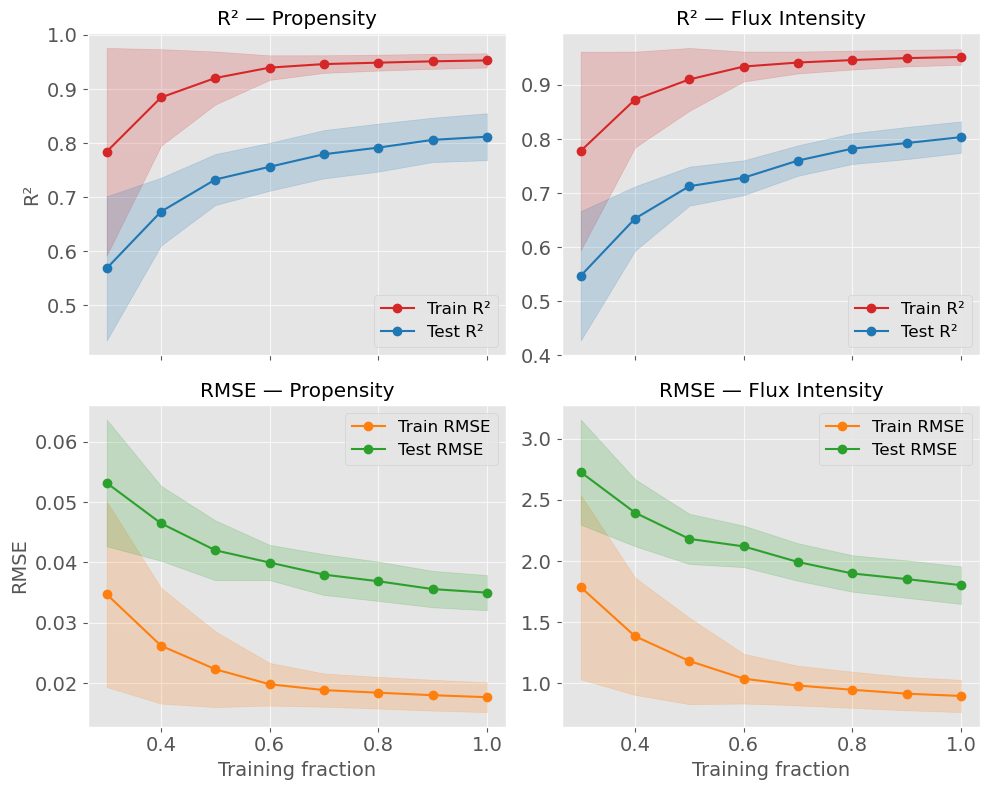

In [3]:
csv_path = Path("../data/ml_output/mt_xgb_results_test_6/ablation_out_labels_sep/xgb_ablation_all_folds_summary.csv")
df = pd.read_csv(csv_path)

g = (
    df.groupby("train_frac", as_index=False)
      .agg(
          R2_train_A_mean=("R2_train_A", "mean"), R2_train_A_sd=("R2_train_A", "std"),
          R2_test_A_mean=("R2_test_A", "mean"), R2_test_A_sd=("R2_test_A", "std"),
          RMSE_train_A_mean=("RMSE_train_A", "mean"), RMSE_train_A_sd=("RMSE_train_A", "std"),
          RMSE_test_A_mean=("RMSE_test_A", "mean"), RMSE_test_A_sd=("RMSE_test_A", "std"),
          R2_train_B_mean=("R2_train_B", "mean"), R2_train_B_sd=("R2_train_B", "std"),
          R2_test_B_mean=("R2_test_B", "mean"), R2_test_B_sd=("R2_test_B", "std"),
          RMSE_train_B_mean=("RMSE_train_B", "mean"), RMSE_train_B_sd=("RMSE_train_B", "std"),
          RMSE_test_B_mean=("RMSE_test_B", "mean"), RMSE_test_B_sd=("RMSE_test_B", "std"),
      )
      .sort_values("train_frac")
)

x = g["train_frac"].values

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
(ax1, ax2), (ax3, ax4) = axes

# --- (A) R² Propensity ---
ax1.plot(x, g["R2_train_A_mean"], "o-", color="tab:red", label="Train R²")
ax1.fill_between(x, g["R2_train_A_mean"]-g["R2_train_A_sd"], g["R2_train_A_mean"]+g["R2_train_A_sd"], color="tab:red", alpha=0.2)
ax1.plot(x, g["R2_test_A_mean"], "o-", color="tab:blue", label="Test R²")
ax1.fill_between(x, g["R2_test_A_mean"]-g["R2_test_A_sd"], g["R2_test_A_mean"]+g["R2_test_A_sd"], color="tab:blue", alpha=0.2)
ax1.set_title("R² — Propensity")
ax1.set_ylabel("R²", fontsize=14)
ax1.grid(True, alpha=0.7)
ax1.tick_params(axis="both", labelsize=14)
ax1.legend(fontsize=12)

# --- (B) R² Flux Intensity ---
ax2.plot(x, g["R2_train_B_mean"], "o-", color="tab:red", label="Train R²")
ax2.fill_between(x, g["R2_train_B_mean"]-g["R2_train_B_sd"], g["R2_train_B_mean"]+g["R2_train_B_sd"], color="tab:red", alpha=0.2)
ax2.plot(x, g["R2_test_B_mean"], "o-", color="tab:blue", label="Test R²")
ax2.fill_between(x, g["R2_test_B_mean"]-g["R2_test_B_sd"], g["R2_test_B_mean"]+g["R2_test_B_sd"], color="tab:blue", alpha=0.2)
ax2.set_title("R² — Flux Intensity")
ax2.tick_params(axis="both", labelsize=14)
ax2.grid(True, alpha=0.7)
ax2.legend(fontsize=12)

# --- (C) RMSE Propensity ---
ax3.plot(x, g["RMSE_train_A_mean"], "o-", color="tab:orange", label="Train RMSE")
ax3.fill_between(x, g["RMSE_train_A_mean"]-g["RMSE_train_A_sd"], g["RMSE_train_A_mean"]+g["RMSE_train_A_sd"], color="tab:orange", alpha=0.2)
ax3.plot(x, g["RMSE_test_A_mean"], "o-", color="tab:green", label="Test RMSE")
ax3.fill_between(x, g["RMSE_test_A_mean"]-g["RMSE_test_A_sd"], g["RMSE_test_A_mean"]+g["RMSE_test_A_sd"], color="tab:green", alpha=0.2)
ax3.set_title("RMSE — Propensity")
ax3.set_xlabel("Training fraction", fontsize=14)
ax3.tick_params(axis="both", labelsize=14)
ax3.set_ylabel("RMSE", fontsize=14)
ax3.grid(True, alpha=0.7)
ax3.legend(fontsize=12)

# --- (D) RMSE Flux Intensity ---
ax4.plot(x, g["RMSE_train_B_mean"], "o-", color="tab:orange", label="Train RMSE")
ax4.fill_between(x, g["RMSE_train_B_mean"]-g["RMSE_train_B_sd"], g["RMSE_train_B_mean"]+g["RMSE_train_B_sd"], color="tab:orange", alpha=0.2)
ax4.plot(x, g["RMSE_test_B_mean"], "o-", color="tab:green", label="Test RMSE")
ax4.fill_between(x, g["RMSE_test_B_mean"]-g["RMSE_test_B_sd"], g["RMSE_test_B_mean"]+g["RMSE_test_B_sd"], color="tab:green", alpha=0.2)
ax4.set_title("RMSE — Flux Intensity")
ax4.set_xlabel("Training fraction", fontsize=14)
ax4.tick_params(axis="both", labelsize=14)
ax4.grid(True, alpha=0.7)
ax4.legend(fontsize=12)

plt.tight_layout()
plt.savefig(csv_path.parent / "ablation_all_folds_per_target.png", dpi=600, bbox_inches="tight")
plt.show()



### Test code

In [ ]:
from sklearn.model_selection import KFold

# Usa una sottosezione dati per test
n_test_samples = min(50, len(X_use))
X_test_sub = X_use.iloc[:n_test_samples, :].copy()
y_test_sub = y[:n_test_samples, :].copy()

# Usa CV piccoli
outer_cv_test = KFold(n_splits=2, shuffle=True, random_state=SEED)
inner_cv_test = KFold(n_splits=2, shuffle=True, random_state=SEED)

# Imposta spazio Hyperopt ridotto
hyperopt_space_test = {
    'n_estimators': hp.qloguniform('n_estimators', np.log(10), np.log(50), 1),
    'max_depth': hp.choice('max_depth', [3, 5]),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-6), np.log(1)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-6), np.log(1)),
    "colsample_bynode":  hp.uniform("colsample_bynode", 0.7, 1),
    "min_child_weight": hp.qloguniform("min_child_weight", np.log(20), np.log(100), 1),
    "gamma": hp.loguniform("gamma", np.log(0.5), np.log(10.0)),
}

# Chiama nested_cv_xgb_phase1 con questi parametri ridotti
meta = nested_cv_xgb_phase1(
    X_df = X_test_sub,
    y_mat = y_test_sub,
    modules = modules,
    use_multi_tree = True,
    outer_cv = outer_cv_test,
    inner_cv = inner_cv_test,
    hyperopt_space = hyperopt_space_test,
    hyperopt_evals = 2,
    interim_eval_every = 1,
    checkpoint_every = 10,
    use_one_se = True,
    n_jobs_inner = 2,
    n_jobs_outer = 2,
    outdir = Path("./test_phase1_output"),
    seed = SEED
)

print("Meta risult test:", meta)

In [ ]:
model_dir = Path("./test_phase1_output")   
out_gain = Path("./test_phase1_output")
extract_importance(model_dir, out_gain, prefix="pipeline_fold_", suffix=".joblib")

[Warn] get_score(gain) failed: [16:47:35] C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.h:256: gain/total_gain  support for multi-target tree is not yet implemented.
Saved importance (type=weight) for fold 1 to test_phase1_output\importance_weight_fold_1.csv
[Warn] get_score(gain) failed: [16:47:36] C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.h:256: gain/total_gain  support for multi-target tree is not yet implemented.
Saved importance (type=weight) for fold 2 to test_phase1_output\importance_weight_fold_2.csv
Done extracting importances for all folds.
